In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import plot_scripts
import analysis_functions as af

In [2]:
metadata = pd.read_csv('data/FLUXNET_Data_Shuttle/FLUXNET_metadata_successful_daily_sites.csv')
metadata.rename(columns={'Site ID': 'Site'}, inplace=True)

# Daily data
df_wue_daily_fluxnet = pd.read_csv('data/FLUXNET_Data_Shuttle/WUE_combined_daily_shuttle.csv')
df_wue_daily_fluxnet['TIMESTAMP'] = pd.to_datetime(df_wue_daily_fluxnet['TIMESTAMP'])
df_wue_daily_fluxnet.rename(columns={'GPP_DT_VUT_50': 'GPP', 'LE_CORR_kg_H2O': 'ET'}, inplace=True)
df_wue_daily_fluxnet.rename(columns={'GPP_DT_VUT_USTAR50': 'GPP', 'LE_CORR_kg_H2O': 'ET'}, inplace=True)
df_wue_daily_fluxnet['ET'] = df_wue_daily_fluxnet['ET'] * 3600 * 24 / 1000  # kg/m2/s -> mm/day

# Half-hourly data
df_wue_hh_fluxnet = pd.read_csv('data/FLUXNET_Data_Shuttle/WUE_combined_halfhourly_shuttle.csv')
df_wue_hh_fluxnet['TIMESTAMP'] = pd.to_datetime(df_wue_hh_fluxnet['Local_Time_30min'], format='%Y-%m-%d %H:%M:%S')
df_wue_hh_fluxnet.rename(columns={'GPP_DT_VUT_50': 'GPP', 'LE_CORR': 'ET'}, inplace=True)
df_wue_hh_fluxnet.rename(columns={'GPP_DT_VUT_USTAR50': 'GPP', 'LE_CORR': 'ET', 'Long': 'Lon'}, inplace=True)

data_folder = 'data/ECOCO3_cleaned/'
date = 'ECOCO3_V1'

os.makedirs('figures/WUE_analysis/', exist_ok=True)

df_wue_daily_ecoco3 = pd.read_csv(data_folder + date + "_df_wue_daily_fullset.csv")
df_wue_hh_ecoco3 = pd.read_csv(data_folder + date + "_df_wue_fullset.csv")
df_wue_hh_ecoco3['LocalTime'] = pd.to_datetime(df_wue_hh_ecoco3['LocalTime'], format='%Y-%m-%d %H:%M:%S')
df_wue_daily_ecoco3['LocalTime'] = pd.to_datetime(df_wue_daily_ecoco3['LocalTime'], format='%Y-%m-%d %H:%M:%S')

# Keep only rows where IGBP class agrees between MODIS and VIIRS
df_wue_hh_ecoco3 = df_wue_hh_ecoco3[df_wue_hh_ecoco3['IGBP_class_MODIS'] == df_wue_hh_ecoco3['IGBP_class_VIIRS']]
df_wue_daily_ecoco3 = df_wue_daily_ecoco3[df_wue_daily_ecoco3['IGBP_class_MODIS'] == df_wue_daily_ecoco3['IGBP_class_VIIRS']]
df_wue_hh_ecoco3.rename(columns={'IGBP_class_MODIS': 'Veg'}, inplace=True)
df_wue_daily_ecoco3.rename(columns={'IGBP_class_MODIS': 'Veg'}, inplace=True)

df_wue_hh_ecoco3['WUE'] = df_wue_hh_ecoco3['WUE_gCkgH20']
df_wue_daily_ecoco3['WUE'] = df_wue_daily_ecoco3['WUE_gCkgH20']
df_wue_hh_ecoco3 = df_wue_hh_ecoco3[df_wue_hh_ecoco3['ET'] > 50]

df_wue_hh_ecoco3 = df_wue_hh_ecoco3.replace([np.inf, -np.inf], np.nan).dropna()
df_wue_daily_ecoco3 = df_wue_daily_ecoco3.replace([np.inf, -np.inf], np.nan).dropna()

df_wue_hh_ecoco3['TIMESTAMP'] = df_wue_hh_ecoco3['LocalTime']
df_wue_daily_ecoco3['TIMESTAMP'] = df_wue_daily_ecoco3['LocalTime']
df_wue_daily_ecoco3['Site'] = df_wue_daily_ecoco3['SiteName']
df_wue_hh_ecoco3['Site'] = df_wue_hh_ecoco3['SiteName']

df_wue_hh_ecoco3['Hour'] = df_wue_hh_ecoco3['TIMESTAMP'].dt.hour
df_wue_daily_ecoco3['Hour'] = df_wue_daily_ecoco3['TIMESTAMP'].dt.hour

df_wue_hh_fluxnet['Hour'] = df_wue_hh_fluxnet['TIMESTAMP'].dt.hour
df_wue_daily_fluxnet['Hour'] = df_wue_daily_fluxnet['TIMESTAMP'].dt.hour    

In [3]:
# ── Thresholds ───────────────────────────────────────────────────────────────
MIN_SCENES     = 500  # half-hourly observations per category per dataset
MIN_SITE_YEARS = 3    # unique (Site × Year) pairs per category per dataset

eco_veg_stats  = af.category_stats(df_wue_hh_ecoco3,  'Veg')
flux_veg_stats = af.category_stats(df_wue_hh_fluxnet, 'Veg')
eco_kg_stats   = af.category_stats(df_wue_hh_ecoco3,  'kg_label')
flux_kg_stats  = af.category_stats(df_wue_hh_fluxnet, 'kg_label')

valid_veg = af.filter_valid(eco_veg_stats, flux_veg_stats, MIN_SCENES, MIN_SITE_YEARS)
valid_kg  = af.filter_valid(eco_kg_stats,  flux_kg_stats, MIN_SCENES, MIN_SITE_YEARS)

# ── Summary ───────────────────────────────────────────────────────────────────
af.print_summary(eco_veg_stats,  flux_veg_stats, valid_veg, "Vegetation types", MIN_SCENES, MIN_SITE_YEARS)
af.print_summary(eco_kg_stats,   flux_kg_stats,  valid_kg,  "Climate classes", MIN_SCENES, MIN_SITE_YEARS)
print(f"\nvalid_veg ({len(valid_veg)}): {valid_veg}")
print(f"valid_kg  ({len(valid_kg)}):  {valid_kg}")


Vegetation types  (MIN_SCENES=500, MIN_SITE_YEARS=3)
                      ECOCO3                   FLUXNET
              scenes  site-yr     scenes  site-yr   kept
  --------------------------------------------------------------
  BSV            362      177     67,303       11   -
  CRO          1,989      600   2,521,459      276   Y
  CSH            126       51    286,782       30   -
  CVM            939      353    262,184       29   Y
  DBF            569      227   1,257,664      143   Y
  DNF              2        2    184,180       20   -
  EBF            509      171    991,460      105   Y
  ENF            846      240   1,784,637      201   Y
  GRA          1,829      562   2,655,508      304   Y
  MF             985      326    324,651       38   Y
  OSH            743      246    657,630       76   Y
  SAV          1,050      375    280,991       34   Y
  SNO              9        8          0        0   -
  URB          1,848      625          0        0   -
  WAT    

In [4]:
RADIUS_KM = 15.0  # "around the tower" radius for pulling in same-vegetation ECOCO3 pixels

# Build (tower, pixel) matches once from half-hourly data (same locations used for daily)
pixel_matches = af.build_tower_pixel_matches(
    df_wue_hh_fluxnet, df_wue_hh_ecoco3,
    radius_km=RADIUS_KM, lat_col='Lat', lon_col='Lon'
)
n_towers = pixel_matches[['site_lat', 'site_lon']].drop_duplicates().shape[0]
n_pixels = pixel_matches[['Lat', 'Lon']].drop_duplicates().shape[0]
print(f"{n_towers} tower(s) matched to {n_pixels} distinct ECOCO3 pixel location(s) "
      f"(same vegetation, within {RADIUS_KM} km)")

# ── Half-hourly ───────────────────────────────────────────────────────────────
df_coincident = af.make_coincident(
    df_wue_hh_fluxnet, df_wue_hh_ecoco3, pixel_matches,
    tolerance=pd.Timedelta('0.25h')
)

df_coincident['TOD'] = df_coincident['TIMESTAMP'].apply(af.assign_time_of_day)
df_coincident = df_coincident.dropna(subset=['TOD'])
print(f"Coincident half-hourly (±0.25 hr, ≤{RADIUS_KM} km, same veg): {len(df_coincident)}")

# ── Daily ─────────────────────────────────────────────────────────────────────
# Daily FLUXNET has 'Long' instead of 'Lon' — rename for the matcher.
# normalize_dates floors ECO overpass times (~13:30) to midnight so
# merge_asof aligns on calendar day; tolerance='12h' keeps same-day only.
df_flux_daily_in = df_wue_daily_fluxnet.rename(columns={'Long': 'Lon'})

df_coincident_daily = af.make_coincident(
    df_flux_daily_in, df_wue_daily_ecoco3, pixel_matches,
    tolerance=pd.Timedelta('12h'), normalize_dates=True
)
print(f"Coincident daily     (±12 h normalized, ≤{RADIUS_KM} km, same veg): {len(df_coincident_daily)}")

3 tower(s) matched to 3 distinct ECOCO3 pixel location(s) (same vegetation, within 15.0 km)


Coincident half-hourly (±0.25 hr, ≤15.0 km, same veg): 10
Coincident daily     (±12 h normalized, ≤15.0 km, same veg): 10


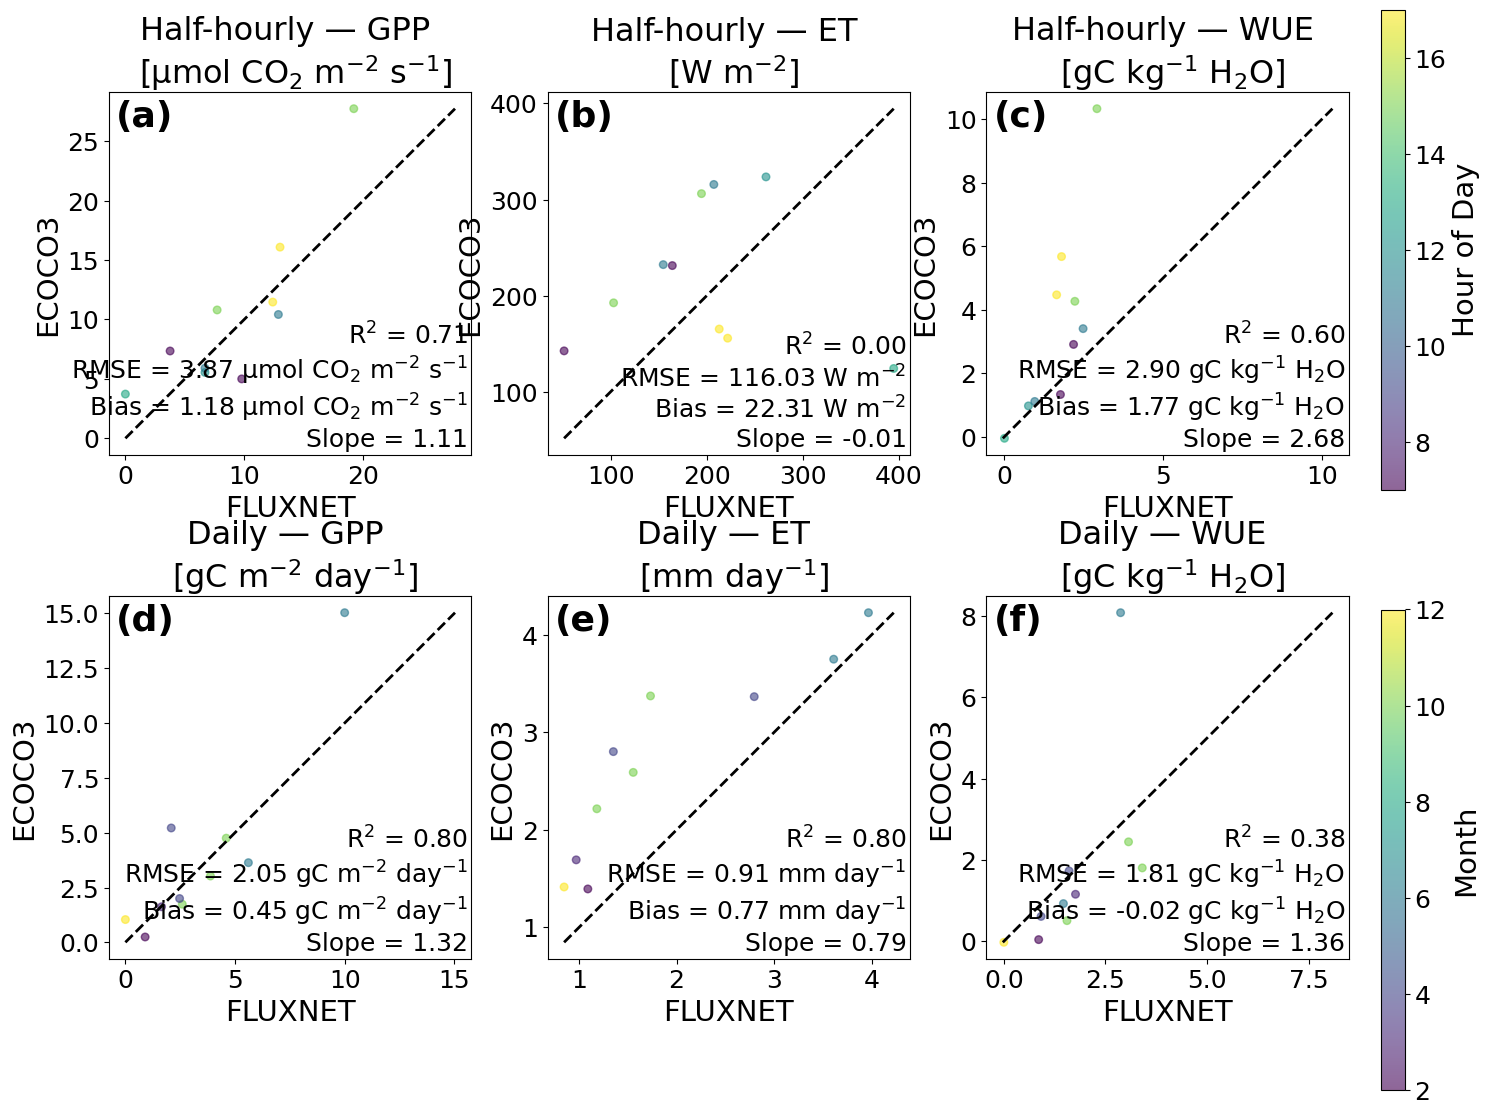

In [5]:
#df_coincident = df_coincident[(df_coincident['WUE_FLUX'] < 10) & (df_coincident['WUE_ECO'] < 10)]
#df_coincident_daily = df_coincident_daily[(df_coincident_daily['WUE_FLUX'] < 10) & (df_coincident_daily['WUE_ECO'] < 10)]
af.plot_flux_vs_eco(df_coincident, df_coincident_daily, output_path='/Users/zoepierratucsb/Library/CloudStorage/GoogleDrive-zpierrat@ucsb.edu/My Drive/PIE_Lab/Projects/ECOCO_Paper/Final_Figures/Figure2.png')

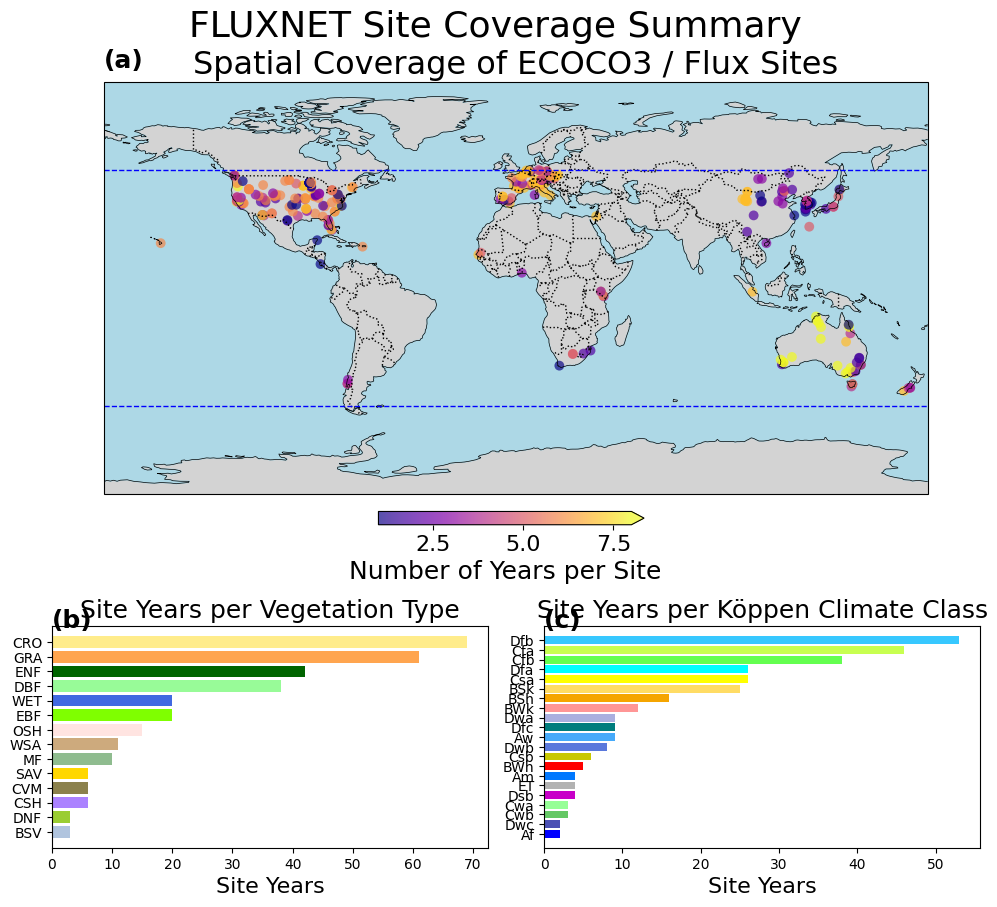

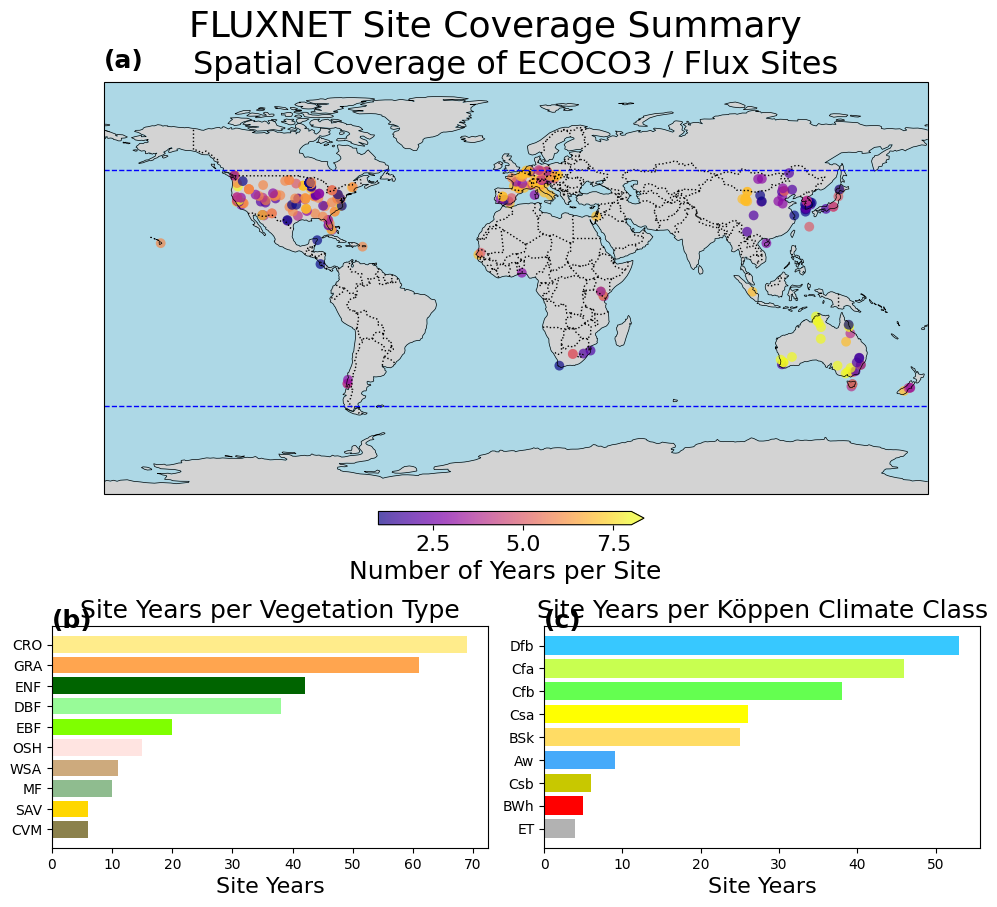

In [6]:
metadata = pd.read_csv('data/FLUXNET_Data_Shuttle/FLUXNET_metadata_successful_daily_sites.csv')

plot_scripts.plot_data_coverage_map_sites(metadata, valid_veg=None, valid_kg=None)
plot_scripts.plot_data_coverage_map_sites(metadata, valid_veg=valid_veg, valid_kg=valid_kg)

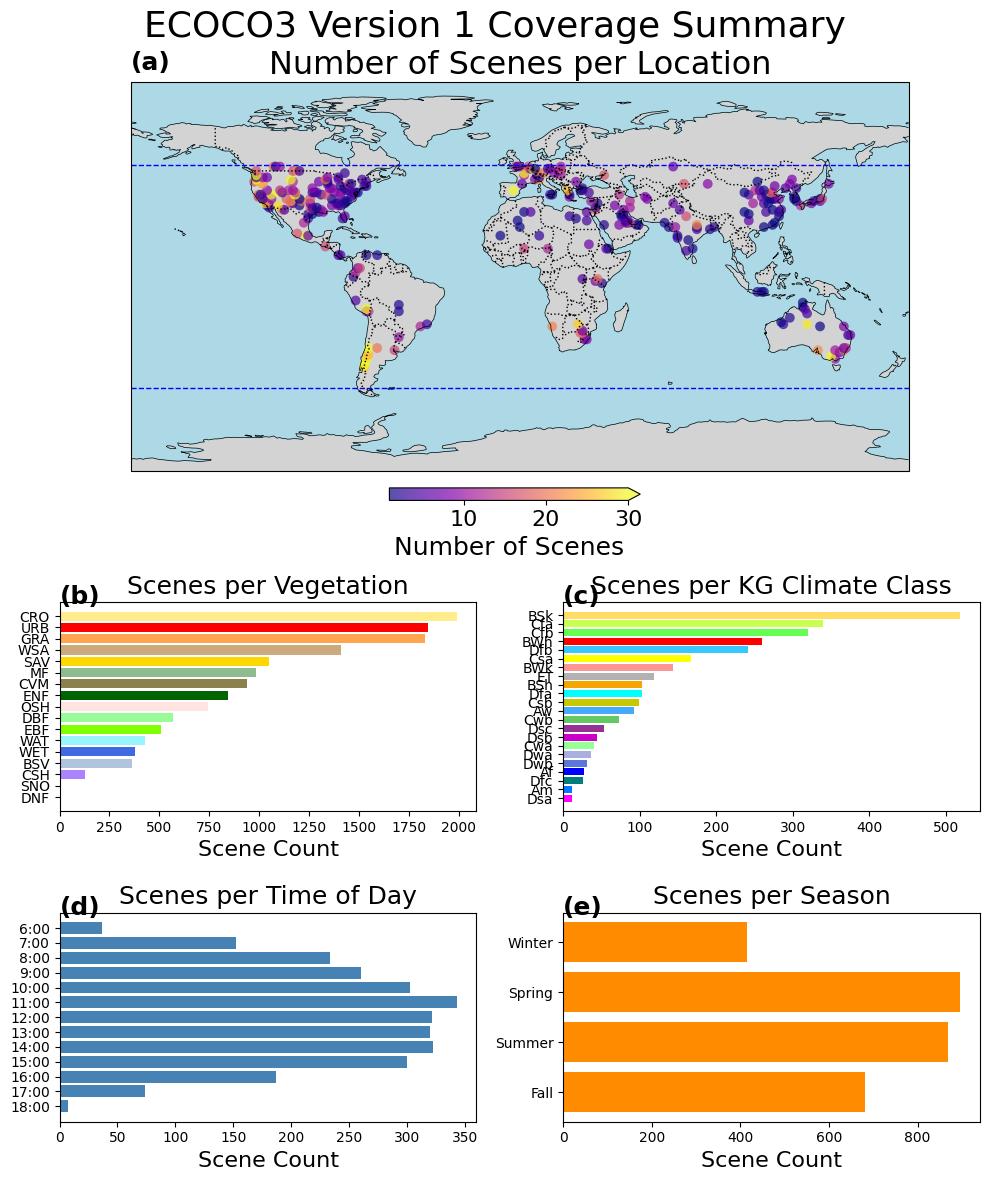

Scenes per vegetation class:
Veg
BSV     362
CRO    1989
CSH     126
CVM     939
DBF     569
DNF       2
EBF     509
ENF     846
GRA    1829
MF      985
OSH     743
SAV    1050
SNO       9
URB    1848
WAT     430
WET     377
WSA    1409
Name: count, dtype: int64

Scenes per climate class:
kg_class
1.0      117
2.0       59
3.0      589
4.0      707
5.0      487
6.0      326
7.0     2363
8.0      951
9.0      595
11.0     272
12.0     379
14.0    2023
15.0    1768
17.0      33
18.0     280
19.0     420
21.0     139
22.0     139
25.0     447
26.0    1184
27.0     123
29.0     621
Name: count, dtype: int64

Total scenes (valid veg AND valid KG): 0


In [7]:
# ======================================================
# Plot ECOCO3 coverage summary: map of scenes per location + bar charts of scenes per vegetation/climate
# ======================================================

#plot_scripts.plot_data_coverage_map(df,valid_kg=valid_kg, valid_veg=valid_veg)
plot_scripts.plot_data_coverage_map(df_wue_hh_ecoco3, output_path='/Users/zoepierratucsb/Library/CloudStorage/GoogleDrive-zpierrat@ucsb.edu/My Drive/PIE_Lab/Projects/ECOCO_Paper/Final_Figures/Figure1.png')
#plot_scripts.plot_data_coverage_map(df_wue_hh_ecoco3, valid_kg=valid_kg, valid_veg=valid_veg)

# ======================================================
# Count scenes per vegetation class
# ======================================================
veg_counts = df_wue_hh_ecoco3['Veg'].value_counts().sort_index()
print("Scenes per vegetation class:")
print(veg_counts)

# ======================================================
# Count scenes per climate class
# ======================================================
kg_counts = df_wue_hh_ecoco3['kg_class'].value_counts().sort_index()
print("\nScenes per climate class:")
print(kg_counts)

df_valid = df_wue_hh_ecoco3[
    df_wue_hh_ecoco3['Veg'].isin(valid_veg) & 
    df_wue_hh_ecoco3['kg_class'].isin(valid_kg)
]
print(f"\nTotal scenes (valid veg AND valid KG): {df_valid.shape[0]}")

In [8]:
df_flux = df_wue_hh_fluxnet[df_wue_hh_fluxnet['Veg'].isin(valid_veg)]
df_ecoco = df_wue_hh_ecoco3[df_wue_hh_ecoco3['Veg'].isin(valid_veg)]
df_flux = df_wue_hh_fluxnet[df_wue_hh_fluxnet['kg_label'].isin(valid_kg)]
df_ecoco = df_wue_hh_ecoco3[df_wue_hh_ecoco3['kg_label'].isin(valid_kg)]

df_flux_summer = df_flux[df_flux['Season'] == 'Summer']
df_ecoco_summer = df_ecoco[df_ecoco['Season'] == 'Summer']

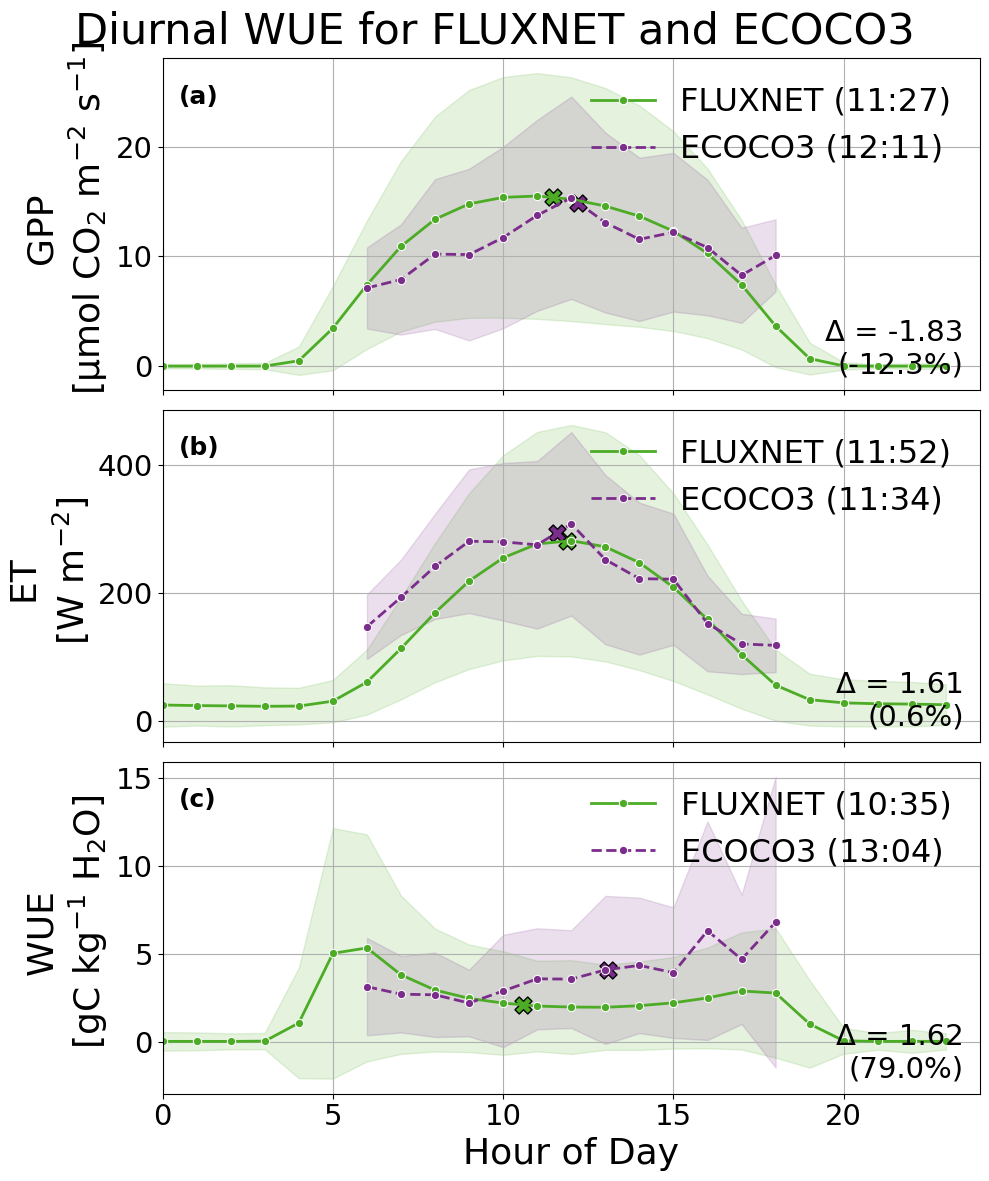

,Variable,Flux Midday Mean,ECOCO Midday Mean,Midday Difference (ECOCO - FLUX),95% CI Lower (bootstrap),95% CI Upper (bootstrap),Flux Centroid (hr),ECOCO Centroid (hr),Flux Centroid (time),ECOCO Centroid (time),Centroid Difference (hr)
0,GPP,14.880609,13.055369,-1.825240,-2.227839,-1.407496,11.450300,12.191435,11:27,12:11,0.741135
1,ET,266.166102,267.772462,1.606360,-5.038748,7.827906,11.876697,11.569498,11:52,11:34,-0.307199
2,WUE,2.046056,3.662819,1.616762,1.462922,1.781893,10.596681,13.082487,10:35,13:04,2.485806


In [9]:
plot_scripts.plot_merged_diurnal_cycles(df_flux_summer, df_ecoco_summer, title='Diurnal WUE for FLUXNET and ECOCO3',
                                        output_path='/Users/zoepierratucsb/Library/CloudStorage/GoogleDrive-zpierrat@ucsb.edu/My Drive/PIE_Lab/Projects/ECOCO_Paper/Final_Figures/Figure4.png')

In [10]:
spei_bins = [
    ("Drought", lambda df: df['SPEI'] < -1.5,),
    ("Non-Drought", lambda df: df['SPEI'] > 0),
]

In [11]:
all_records = []
supp_records = []
shift_records = []

for var in valid_veg:
    df_ecoco_var = df_ecoco_summer[df_ecoco_summer['Veg'] == var]
    df_flux_var  = df_flux_summer[df_flux_summer['Veg'] == var]

    df_ecoco_centroids = plot_scripts.plot_diurnal_cycles_spei(
        df_ecoco_var, spei_bins, title=f'Diurnal WUE by Vegetation Type (ECOCO) - {var}'
    )
    df_flux_centroids = plot_scripts.plot_diurnal_cycles_spei(
        df_flux_var, spei_bins, title=f'Diurnal WUE by Vegetation Type (FLUXNET) - {var}'
    )

    df_ecoco_centroids['veg'] = var
    df_ecoco_centroids['dataset'] = 'ECOCO'
    df_flux_centroids['veg'] = var
    df_flux_centroids['dataset'] = 'FLUXNET'

    all_records += [df_ecoco_centroids, df_flux_centroids]

    ecoco_supp = df_ecoco_centroids[df_ecoco_centroids["SPEI Bin"] == "Midday drought - non-drought"].copy()
    flux_supp  = df_flux_centroids[df_flux_centroids["SPEI Bin"] == "Midday drought - non-drought"].copy()
    ecoco_supp[["veg", "dataset"]] = var, "ECOCO"
    flux_supp[["veg", "dataset"]]  = var, "FLUXNET"
    supp_records += [ecoco_supp, flux_supp]

    ecoco_shift = df_ecoco_centroids[df_ecoco_centroids["SPEI Bin"] == "Centroid shift (Drought - Non-Drought)"].copy()
    flux_shift  = df_flux_centroids[df_flux_centroids["SPEI Bin"] == "Centroid shift (Drought - Non-Drought)"].copy()
    ecoco_shift[["veg", "dataset"]] = var, "ECOCO"
    flux_shift[["veg", "dataset"]]  = var, "FLUXNET"
    shift_records += [ecoco_shift, flux_shift]

df_centroids = pd.concat(all_records, ignore_index=True)
df_supp = pd.concat(supp_records, ignore_index=True)
df_shift = pd.concat(shift_records, ignore_index=True)

df_pivot = df_centroids.pivot_table(
    index=['Variable', 'veg', 'SPEI Bin'],
    columns='dataset',
    values='Centroid Hour'
).reset_index()

df_pivot['Difference (hrs)'] = (df_pivot['ECOCO'] - df_pivot['FLUXNET']).round(2)
df_pivot = df_pivot.dropna()

df_pivot['ECOCO']   = df_pivot['ECOCO'].apply(plot_scripts.hour_to_timestamp)
df_pivot['FLUXNET'] = df_pivot['FLUXNET'].apply(plot_scripts.hour_to_timestamp)

df_pivot_supp = df_supp.pivot_table(
    index=['Variable', 'veg'],
    columns='dataset',
    values=['Midday Δ', 'CI 2.5%', 'CI 97.5%', '% Change', 'N drought days', 'N non-drought days'],
    aggfunc='mean'
).reset_index()

df_pivot = df_pivot.round(2)
df_pivot_supp = df_pivot_supp.round(2)

df_shift['dataset'] = pd.Categorical(df_shift['dataset'], categories=['ECOCO', 'FLUXNET'])
df_pivot_shift = df_shift.pivot_table(
    index=['Variable', 'veg'],
    columns='dataset',
    values=['Centroid Shift (hrs)', 'Shift CI 2.5%', 'Shift CI 97.5%'],
    aggfunc='mean',
    dropna=False,
    observed=False
).reset_index()
df_pivot_shift = df_pivot_shift.round(2)

df_pivot.to_csv('tables/centroid_summary.csv', index=False)
df_pivot_supp.to_csv('tables/suppression_summary_midday.csv', index=False)
df_pivot_shift.to_csv('tables/centroid_shift_summary.csv', index=False)

/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:535: RuntimeWarning: invalid value encountered in scalar divide
  boot_hour[b] = np.sum(unique_hours * means) / np.sum(means)


/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:535: RuntimeWarning: invalid value encountered in scalar divide
  boot_hour[b] = np.sum(unique_hours * means) / np.sum(means)


In [12]:
all_records = []
supp_records = []
shift_records = []

for var in valid_kg:
    df_ecoco_var = df_ecoco_summer[df_ecoco_summer['kg_label'] == var]
    df_flux_var  = df_flux_summer[df_flux_summer['kg_label'] == var]

    df_ecoco_centroids = plot_scripts.plot_diurnal_cycles_spei(
        df_ecoco_var, spei_bins, title=f'Diurnal WUE by Climate Type (ECOCO) - {var}'
    )
    df_flux_centroids = plot_scripts.plot_diurnal_cycles_spei(
        df_flux_var, spei_bins, title=f'Diurnal WUE by Climate Type (FLUXNET) - {var}'
    )

    df_ecoco_centroids['kg_label'] = var
    df_ecoco_centroids['dataset'] = 'ECOCO'
    df_flux_centroids['kg_label'] = var
    df_flux_centroids['dataset'] = 'FLUXNET'

    all_records += [df_ecoco_centroids, df_flux_centroids]

    if len(df_ecoco_centroids) == 0 or len(df_flux_centroids) == 0:
        continue

    ecoco_supp = df_ecoco_centroids[df_ecoco_centroids["SPEI Bin"] == "Midday drought - non-drought"].copy()
    flux_supp  = df_flux_centroids[df_flux_centroids["SPEI Bin"] == "Midday drought - non-drought"].copy()
    ecoco_supp[["kg_label", "dataset"]] = var, "ECOCO"
    flux_supp[["kg_label", "dataset"]]  = var, "FLUXNET"
    supp_records += [ecoco_supp, flux_supp]

    ecoco_shift = df_ecoco_centroids[df_ecoco_centroids["SPEI Bin"] == "Centroid shift (Drought - Non-Drought)"].copy()
    flux_shift  = df_flux_centroids[df_flux_centroids["SPEI Bin"] == "Centroid shift (Drought - Non-Drought)"].copy()
    ecoco_shift[["kg_label", "dataset"]] = var, "ECOCO"
    flux_shift[["kg_label", "dataset"]]  = var, "FLUXNET"
    shift_records += [ecoco_shift, flux_shift]

df_centroids = pd.concat(all_records, ignore_index=True)
df_supp = pd.concat(supp_records, ignore_index=True)
df_shift = pd.concat(shift_records, ignore_index=True)

df_pivot = df_centroids.pivot_table(
    index=['Variable', 'kg_label', 'SPEI Bin'],
    columns='dataset',
    values='Centroid Hour'
).reset_index()

df_pivot['Difference (hrs)'] = (df_pivot['ECOCO'] - df_pivot['FLUXNET']).round(2)
df_pivot = df_pivot.dropna()

df_pivot['ECOCO']   = df_pivot['ECOCO'].apply(plot_scripts.hour_to_timestamp)
df_pivot['FLUXNET'] = df_pivot['FLUXNET'].apply(plot_scripts.hour_to_timestamp)

df_pivot_supp = df_supp.pivot_table(
    index=['Variable', 'kg_label'],
    columns='dataset',
    values=['Midday Δ', 'CI 2.5%', 'CI 97.5%', '% Change', 'N drought days', 'N non-drought days'],
    aggfunc='mean'
).reset_index()

df_pivot = df_pivot.round(2)
df_pivot_supp = df_pivot_supp.round(2).dropna()

df_shift['dataset'] = pd.Categorical(df_shift['dataset'], categories=['ECOCO', 'FLUXNET'])
df_pivot_shift = df_shift.pivot_table(
    index=['Variable', 'kg_label'],
    columns='dataset',
    values=['Centroid Shift (hrs)', 'Shift CI 2.5%', 'Shift CI 97.5%'],
    aggfunc='mean',
    dropna=False,
    observed=False
).reset_index()
df_pivot_shift = df_pivot_shift.round(2)

df_pivot.to_csv('tables/centroid_summary_kg.csv', index=False)
df_pivot_supp.to_csv('tables/suppression_summary_midday_kg.csv', index=False)
df_pivot_shift.to_csv('tables/centroid_shift_summary_kg.csv', index=False)

In [13]:
print(df_pivot_supp.to_string(index=False)) 

Variable kg_label % Change         CI 2.5%         CI 97.5%         Midday Δ         N drought days         N non-drought days        
                     ECOCO FLUXNET   ECOCO FLUXNET    ECOCO FLUXNET    ECOCO FLUXNET          ECOCO FLUXNET              ECOCO FLUXNET
      ET      BSk    -9.90  -32.86  -92.88  -72.42    40.92  -51.94   -25.68  -62.44           10.0   527.0               24.0   866.0
      ET      Cfb   -29.49  -14.62 -162.21  -48.61   -64.74  -31.06  -114.47  -40.09            7.0   663.0               23.0  1152.0
      ET      Dfb   -11.89    4.63 -145.99    1.63    98.28   22.44   -29.17   12.36            6.0   460.0               28.0   705.0
     GPP      BSk   -11.53  -24.22   -3.45   -2.27     1.33   -1.11    -1.09   -1.73           10.0   527.0               24.0   866.0
     GPP      Cfb   -36.92  -11.29   -9.34   -2.51    -4.49   -1.21    -6.92   -1.88            7.0   663.0               23.0  1152.0
     GPP      Dfb    -8.69    0.12   -6.18   -0.63     

In [14]:
print(df_pivot.to_string(index=False))

Variable kg_label    SPEI Bin ECOCO FLUXNET  Difference (hrs)
      ET       Aw Non-Drought 10:06   11:47             -1.68
      ET      BSk     Drought 11:50   11:54             -0.06
      ET      BSk Non-Drought 11:46   11:49             -0.06
      ET      BWh     Drought 10:57   11:55             -0.96
      ET      BWh Non-Drought 09:27   11:50             -2.37
      ET      Cfa     Drought 11:38   11:52             -0.23
      ET      Cfa Non-Drought 11:26   11:50             -0.40
      ET      Cfb     Drought 11:41   11:45             -0.06
      ET      Cfb Non-Drought 11:42   11:55             -0.23
      ET      Csa     Drought 10:57   12:00             -1.05
      ET      Csa Non-Drought 11:13   12:00             -0.79
      ET      Csb     Drought 11:07   11:48             -0.69
      ET      Csb Non-Drought 10:21   11:56             -1.59
      ET      Dfb     Drought 12:19   11:44              0.58
      ET      Dfb Non-Drought 11:20   11:45             -0.41
      ET

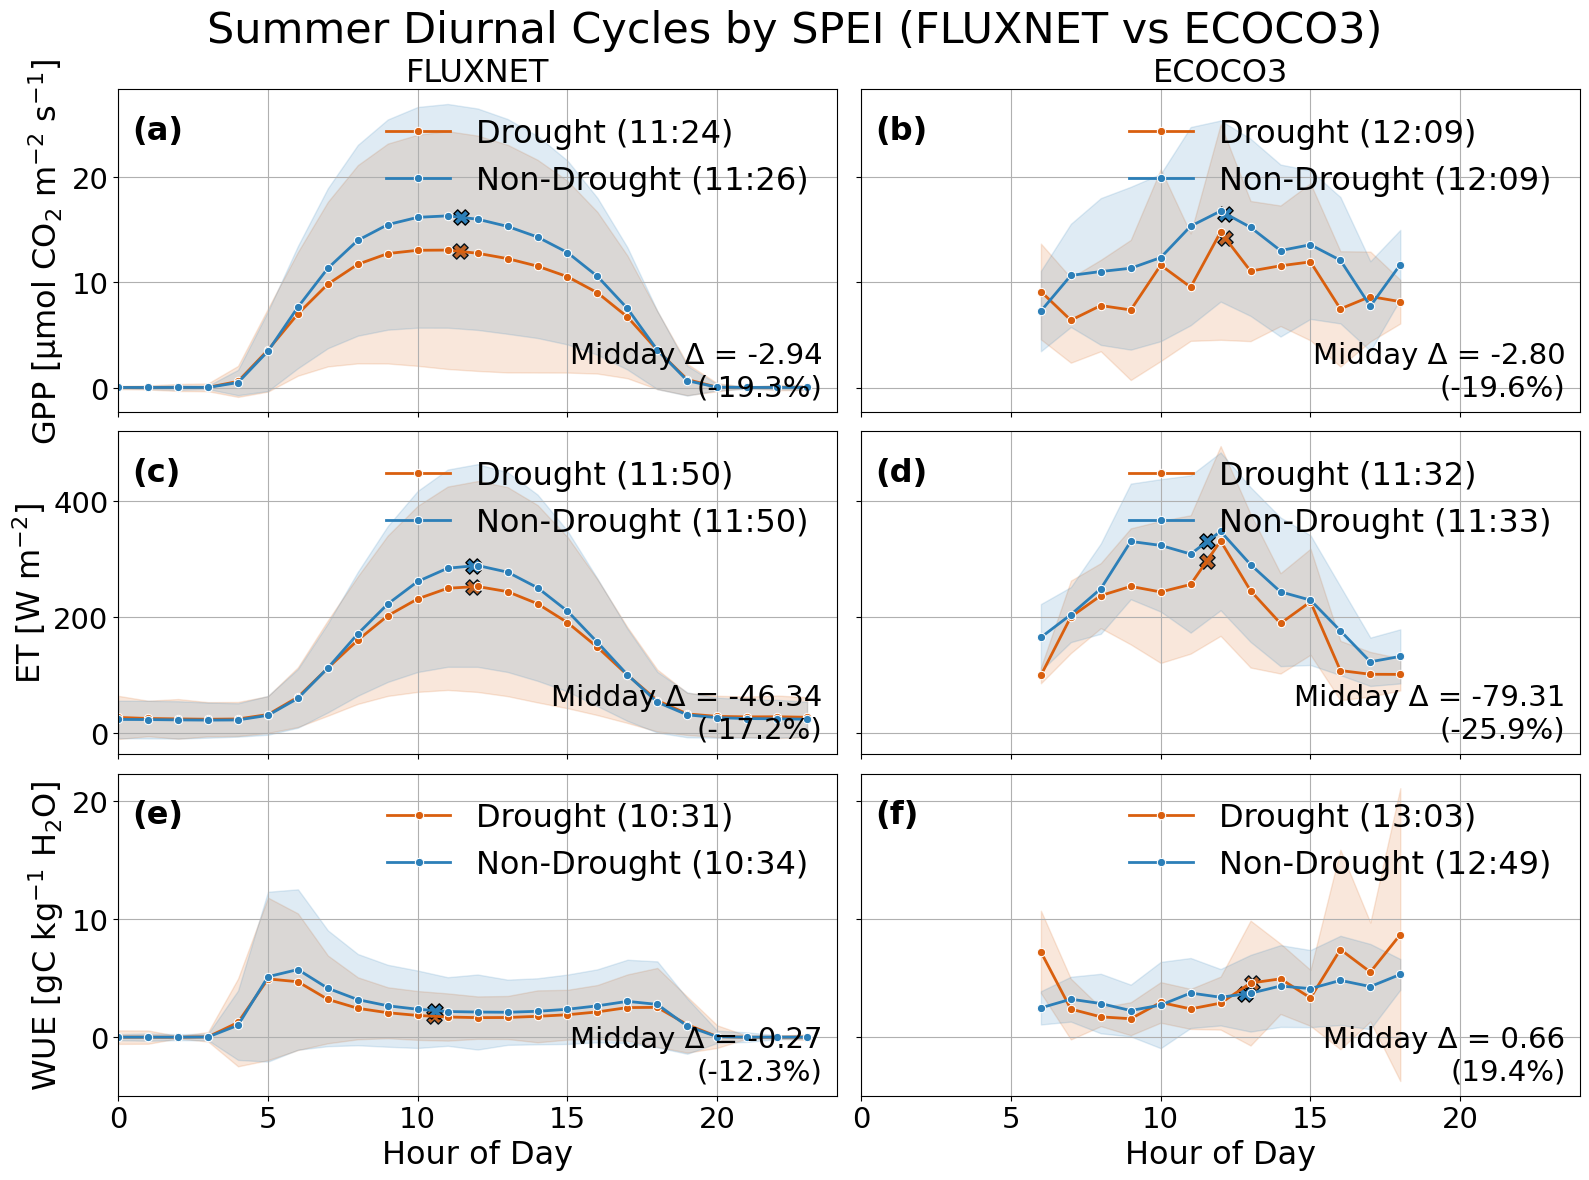

,Dataset,Variable,SPEI Bin,Centroid Hour,Centroid Time,Midday Δ,% Change,CI 2.5%,CI 97.5%,N drought days,N non-drought days
0,FLUXNET,GPP,Drought,11.410797,11:24,NaN,NaN,NaN,NaN,NaN,NaN
1,FLUXNET,GPP,Non-Drought,11.436894,11:26,NaN,NaN,NaN,NaN,NaN,NaN
2,FLUXNET,GPP,Midday drought - non-drought,NaN,NaN,-2.935908,-19.298692,-3.294020,-2.549195,1247.0,1399.0
3,ECOCO3,GPP,Drought,12.154020,12:09,NaN,NaN,NaN,NaN,NaN,NaN
4,ECOCO3,GPP,Non-Drought,12.152668,12:09,NaN,NaN,NaN,NaN,NaN,NaN
5,ECOCO3,GPP,Midday drought - non-drought,NaN,NaN,-2.802859,-19.640511,-5.311317,-0.222892,41.0,79.0
6,FLUXNET,ET,Drought,11.847855,11:50,NaN,NaN,NaN,NaN,NaN,NaN
7,FLUXNET,ET,Non-Drought,11.846728,11:50,NaN,NaN,NaN,NaN,NaN,NaN
8,FLUXNET,ET,Midday drought - non-drought,NaN,NaN,-46.338067,-17.228478,-52.115147,-39.823365,1247.0,1399.0
9,ECOCO3,ET,Drought,11.536586,11:32,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
plot_scripts.plot_diurnal_cycles_spei_comparison(
    df_ecoco3=df_ecoco_summer,
    df_fluxnet=df_flux_summer,
    spei_bins=spei_bins,
    title='Summer Diurnal Cycles by SPEI',
    output_path='/Users/zoepierratucsb/Library/CloudStorage/GoogleDrive-zpierrat@ucsb.edu/My Drive/PIE_Lab/Projects/ECOCO_Paper/Final_Figures/Figure5.png'
)

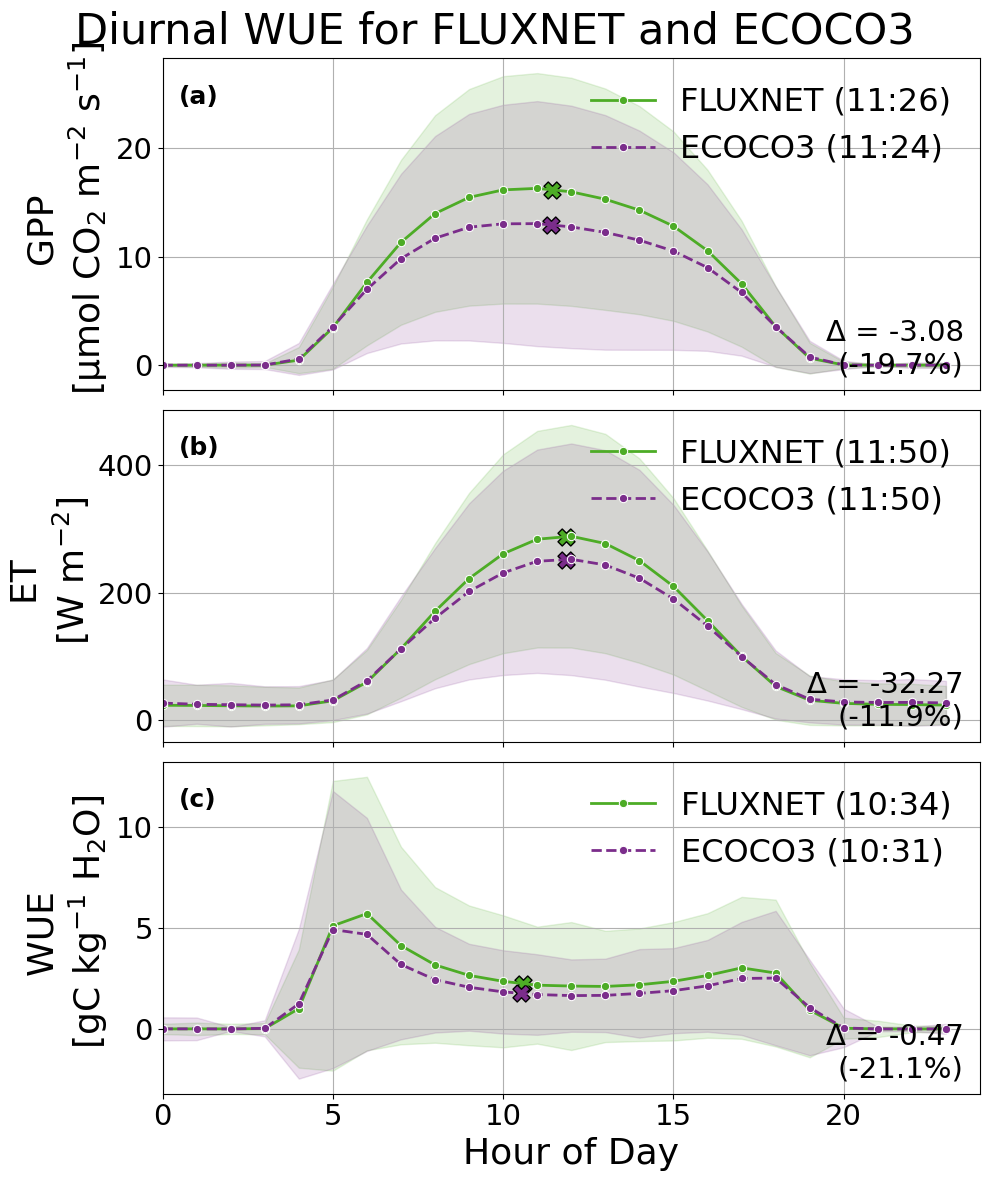

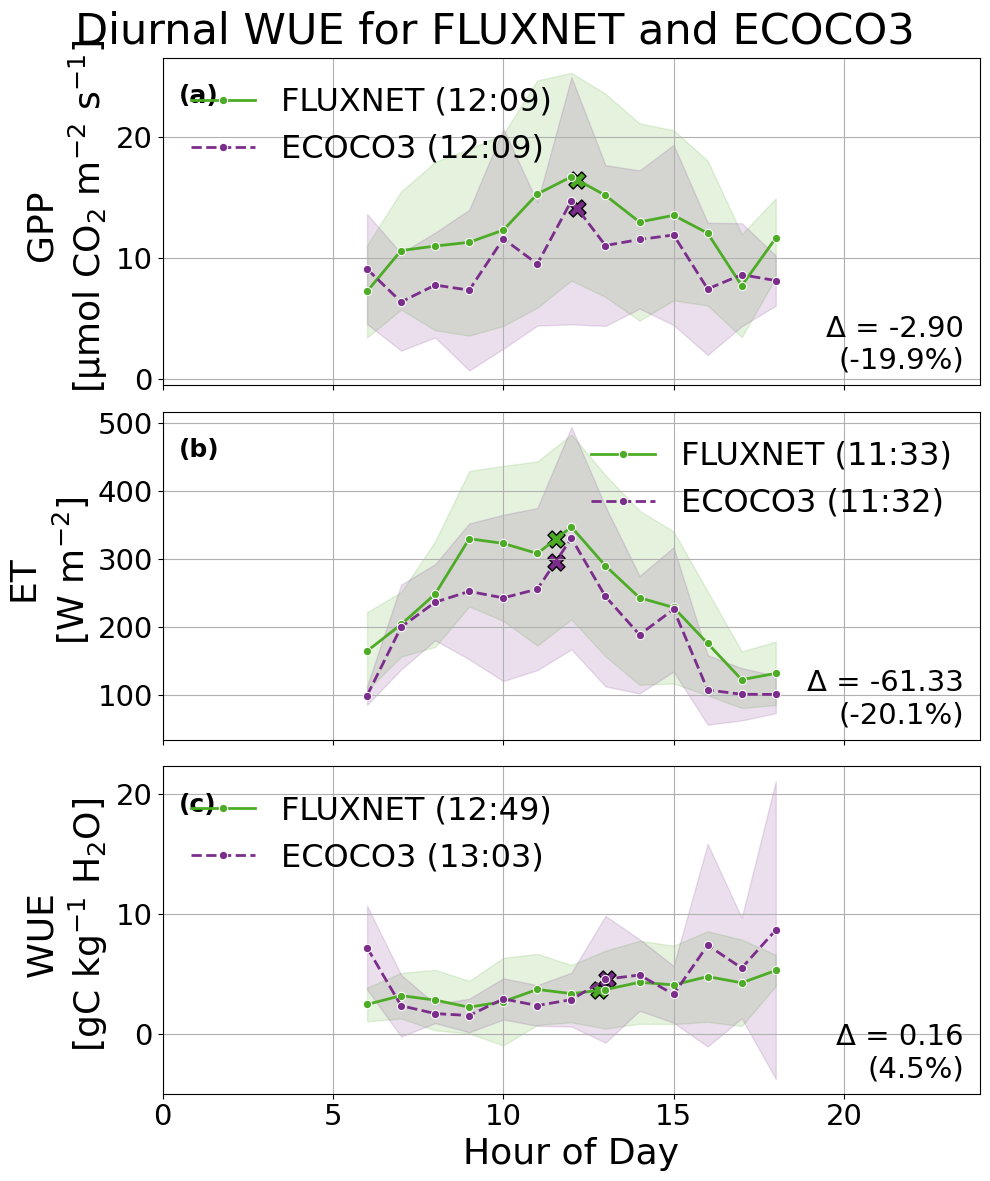

,Variable,Flux Midday Mean,ECOCO Midday Mean,Midday Difference (ECOCO - FLUX),95% CI Lower (bootstrap),95% CI Upper (bootstrap),Flux Centroid (hr),ECOCO Centroid (hr),Flux Centroid (time),ECOCO Centroid (time),Centroid Difference (hr)
0,GPP,14.520216,11.624479,-2.895738,-4.014875,-1.717333,12.152668,12.154020,12:09,12:09,0.001351
1,ET,304.714288,243.386558,-61.327729,-79.208188,-41.977101,11.559314,11.536586,11:33,11:32,-0.022728
2,WUE,3.524734,3.684167,0.159434,-0.286700,0.639356,12.821830,13.053744,12:49,13:03,0.231914


In [16]:
# The figures that this produces have the wrong title I just need to clean this up for final publication 
plot_scripts.plot_merged_diurnal_cycles(df_flux_summer[df_flux_summer['SPEI'] > 0], df_flux_summer[df_flux_summer['SPEI'] < -1.5], title='Diurnal WUE for FLUXNET and ECOCO3')
plot_scripts.plot_merged_diurnal_cycles(df_ecoco_summer[df_ecoco_summer['SPEI'] > 0], df_ecoco_summer[df_ecoco_summer['SPEI'] < -1.5], title='Diurnal WUE for FLUXNET and ECOCO3')

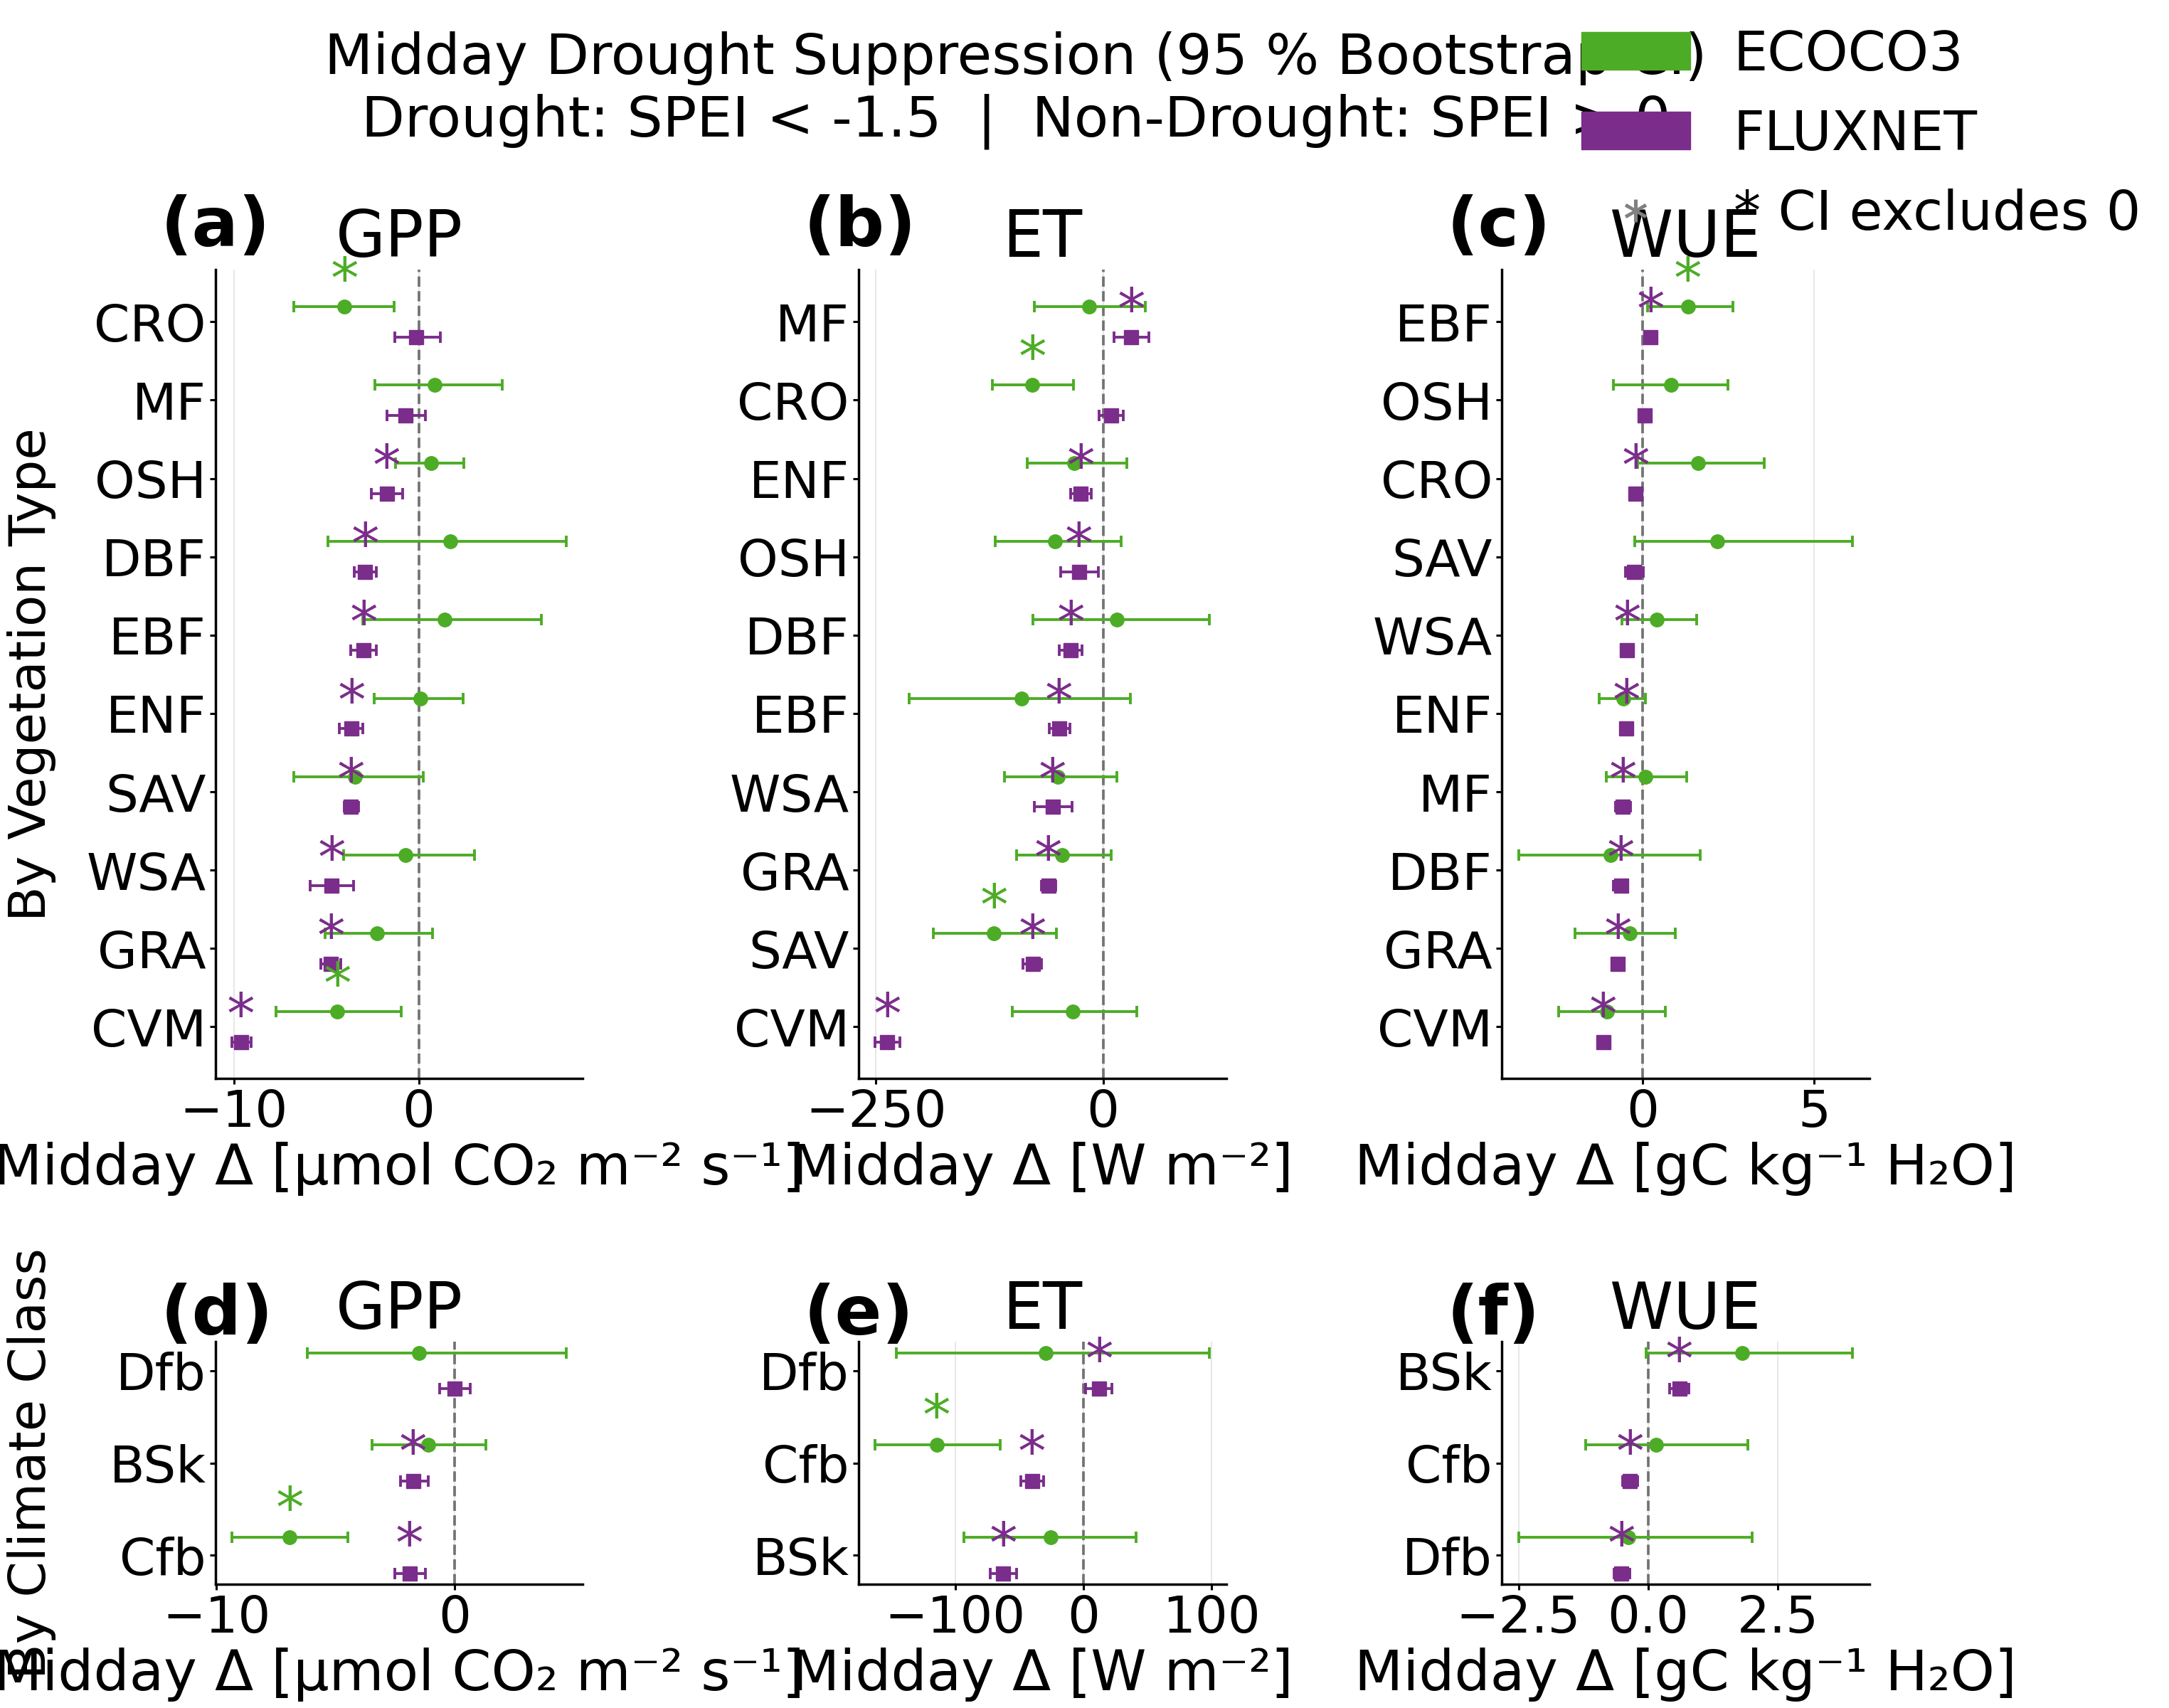

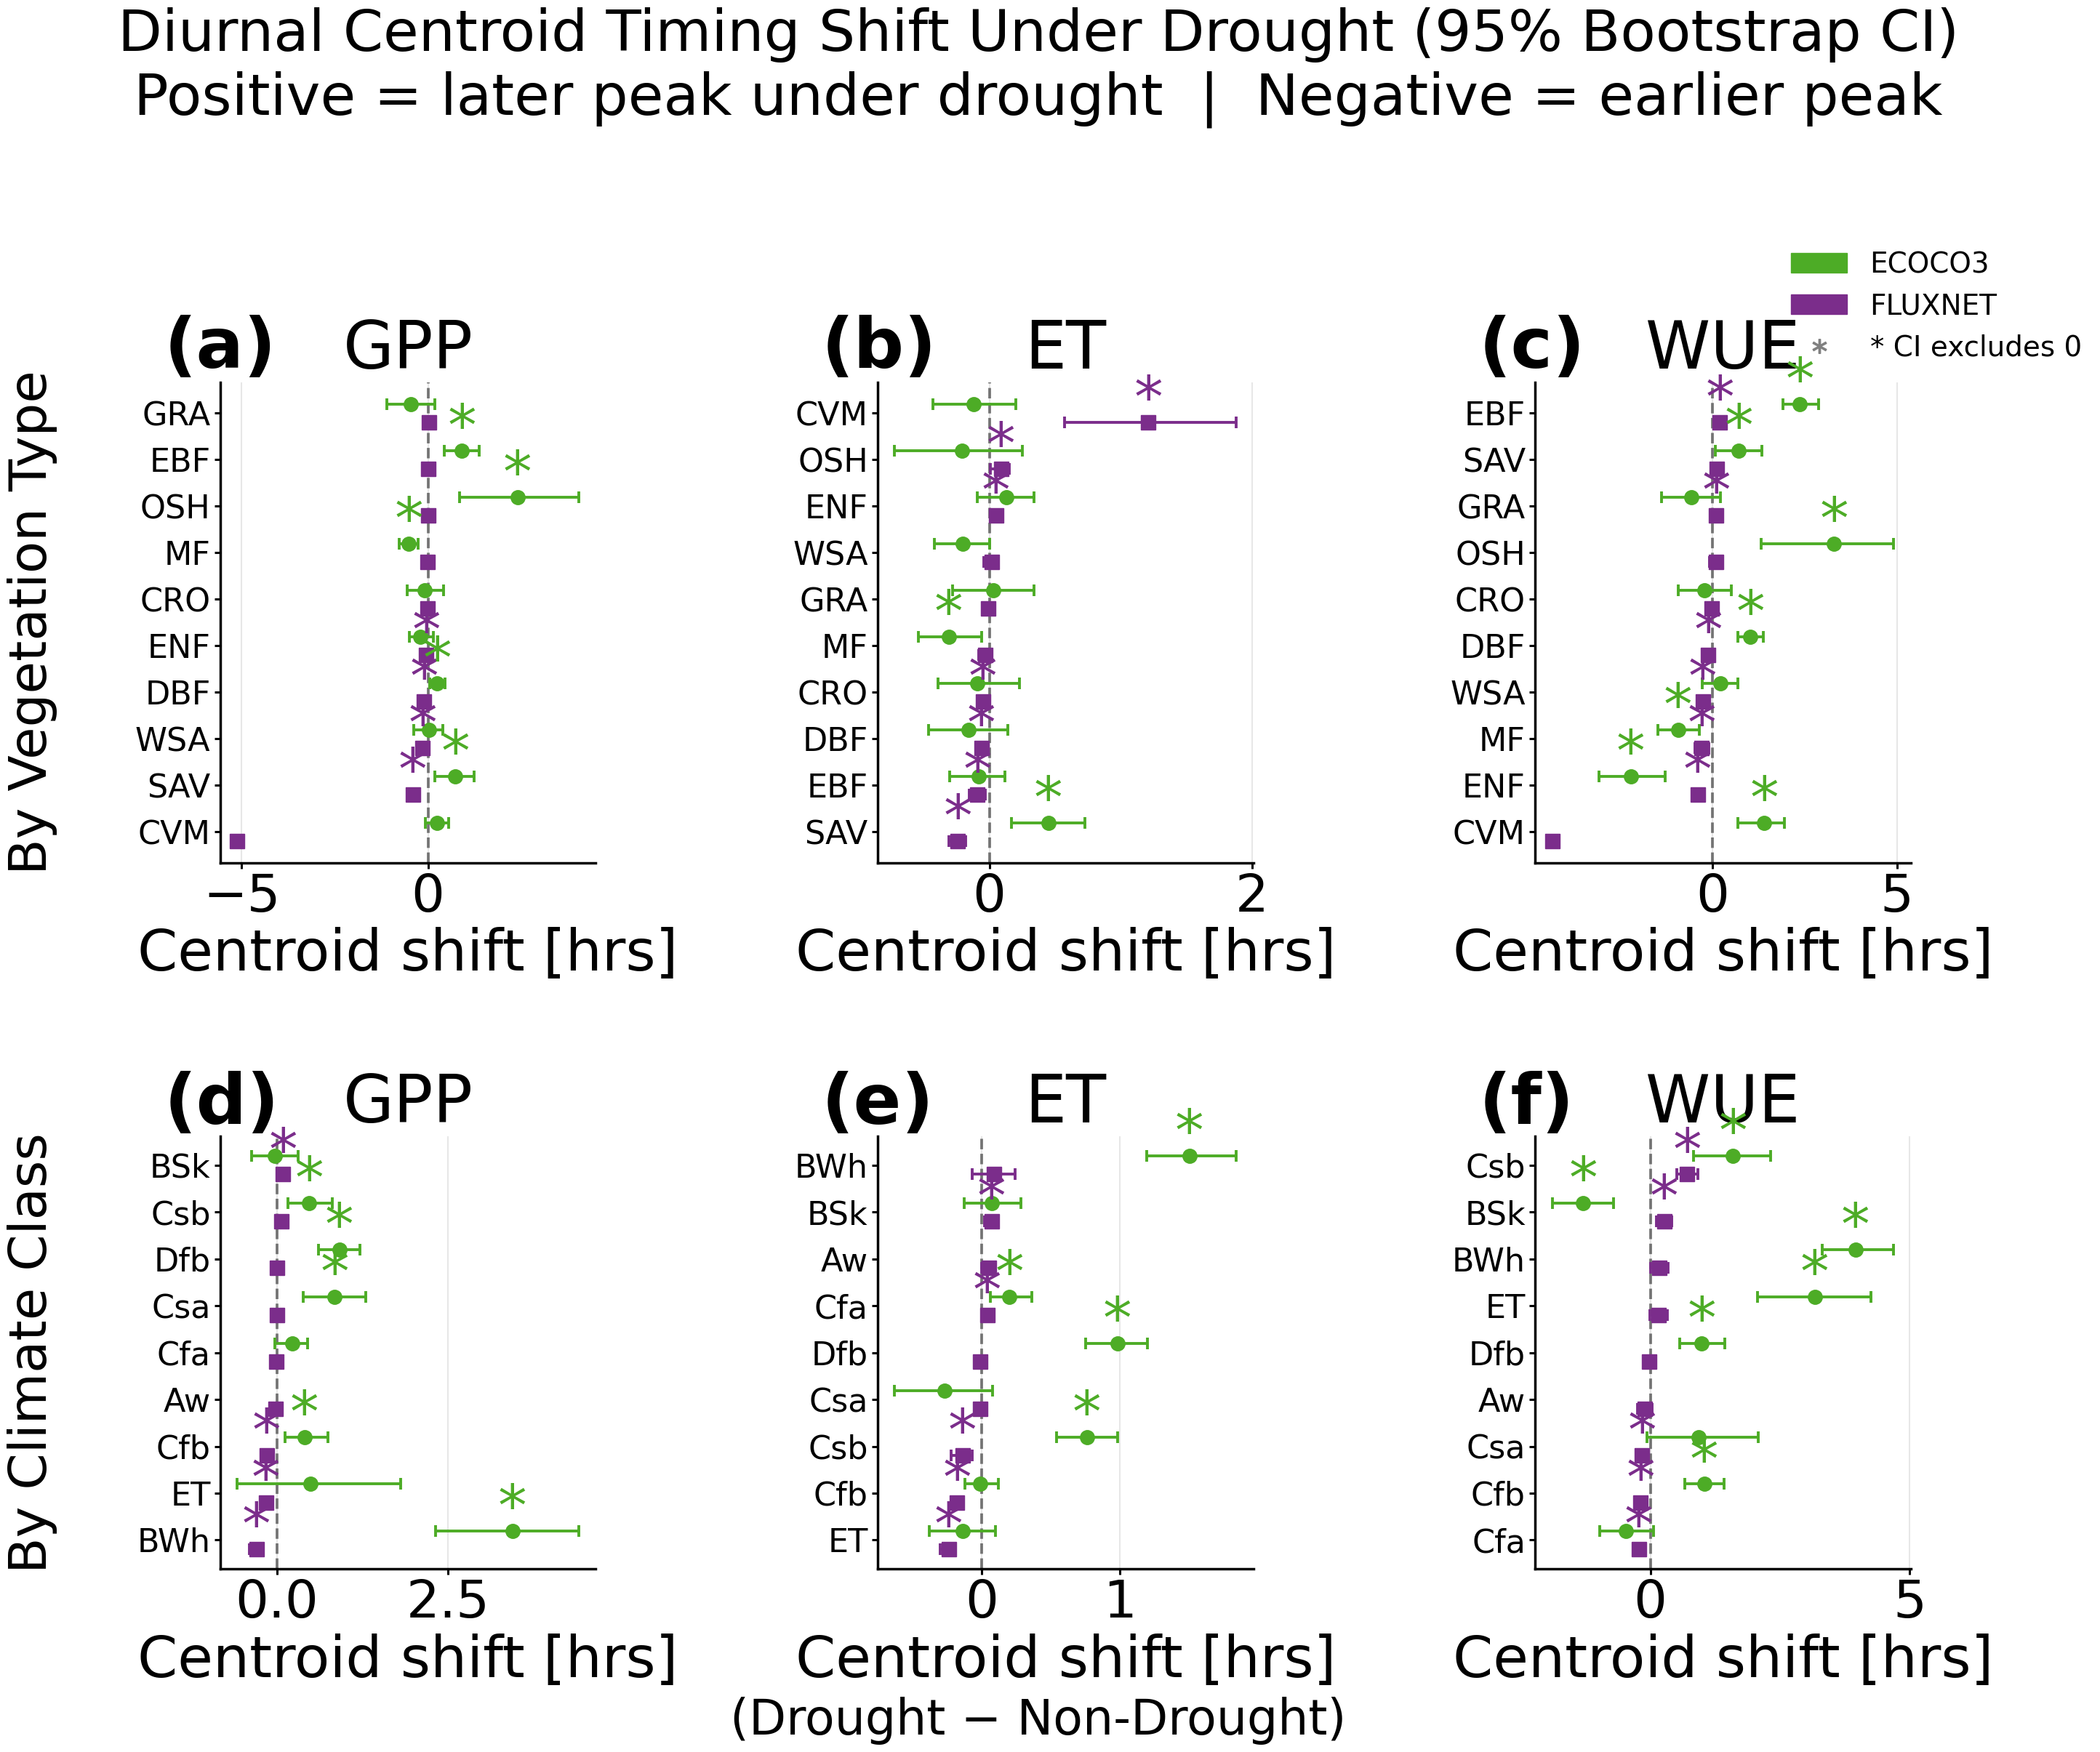

In [17]:
plot_scripts.plot_drought_suppression_summary()
plot_scripts.plot_centroid_shift_summary()

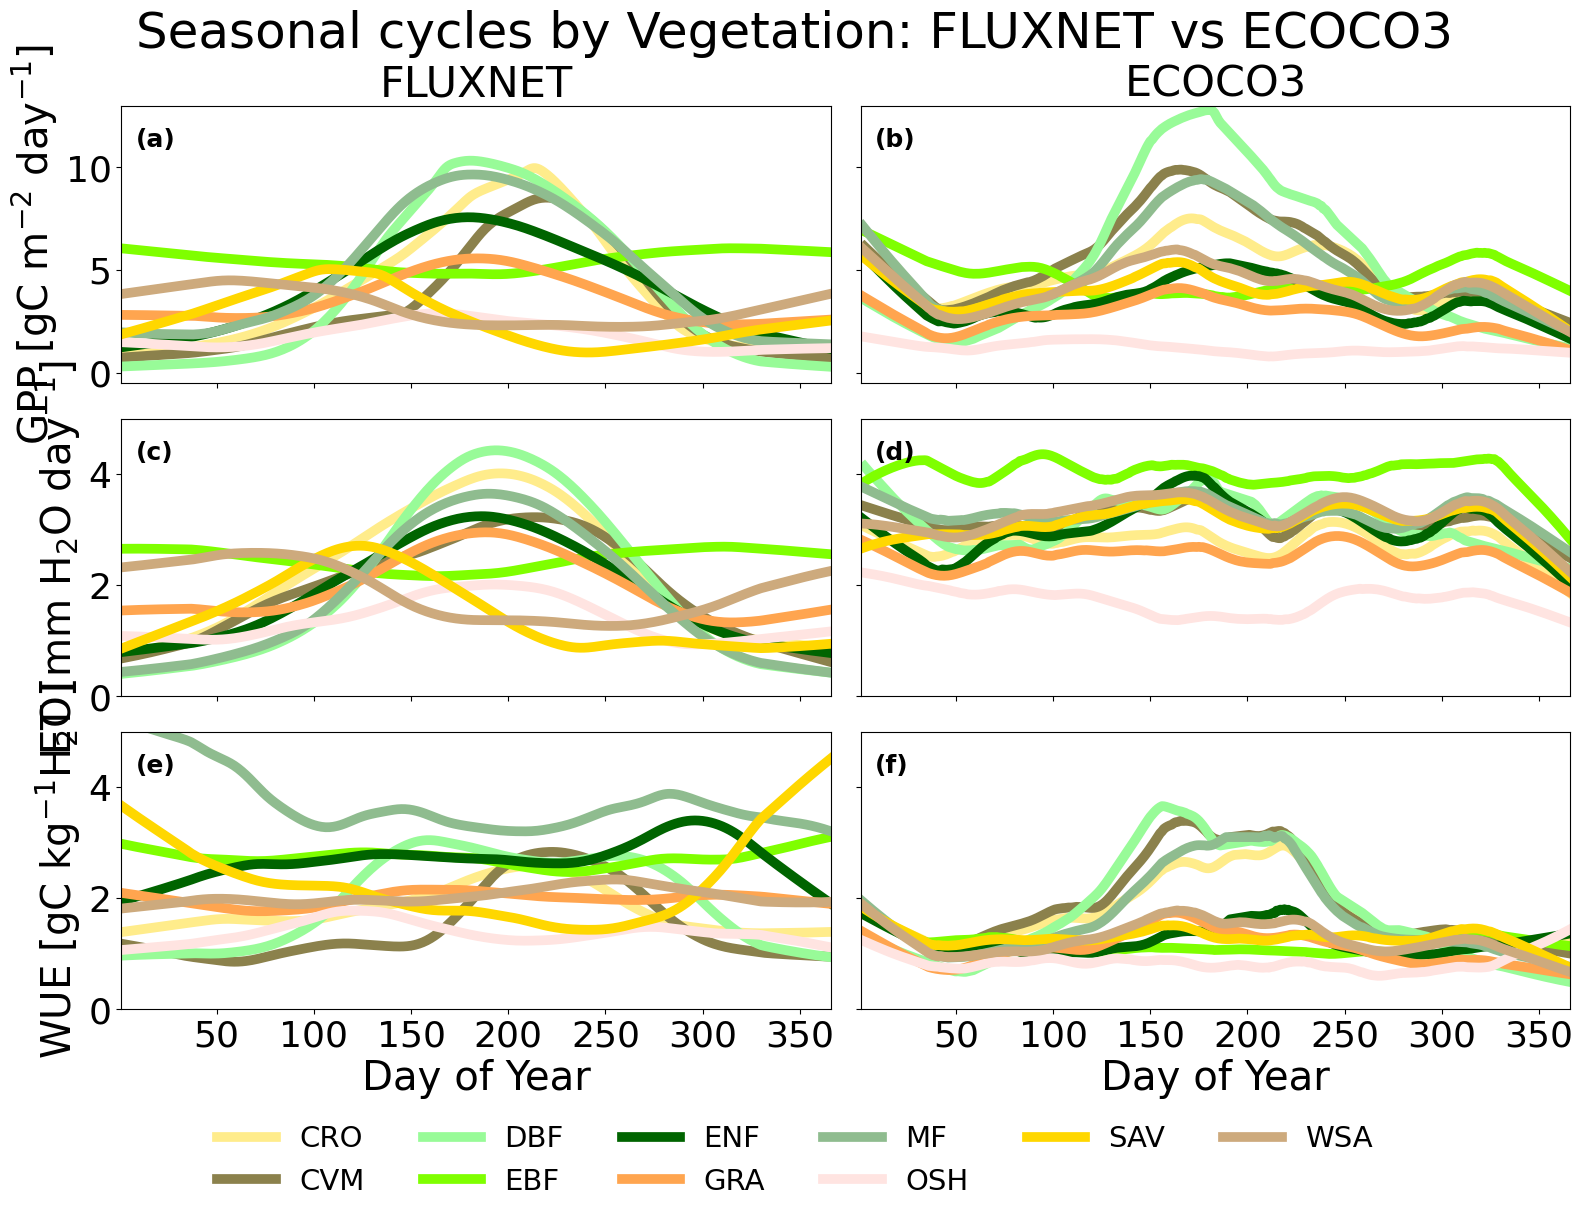

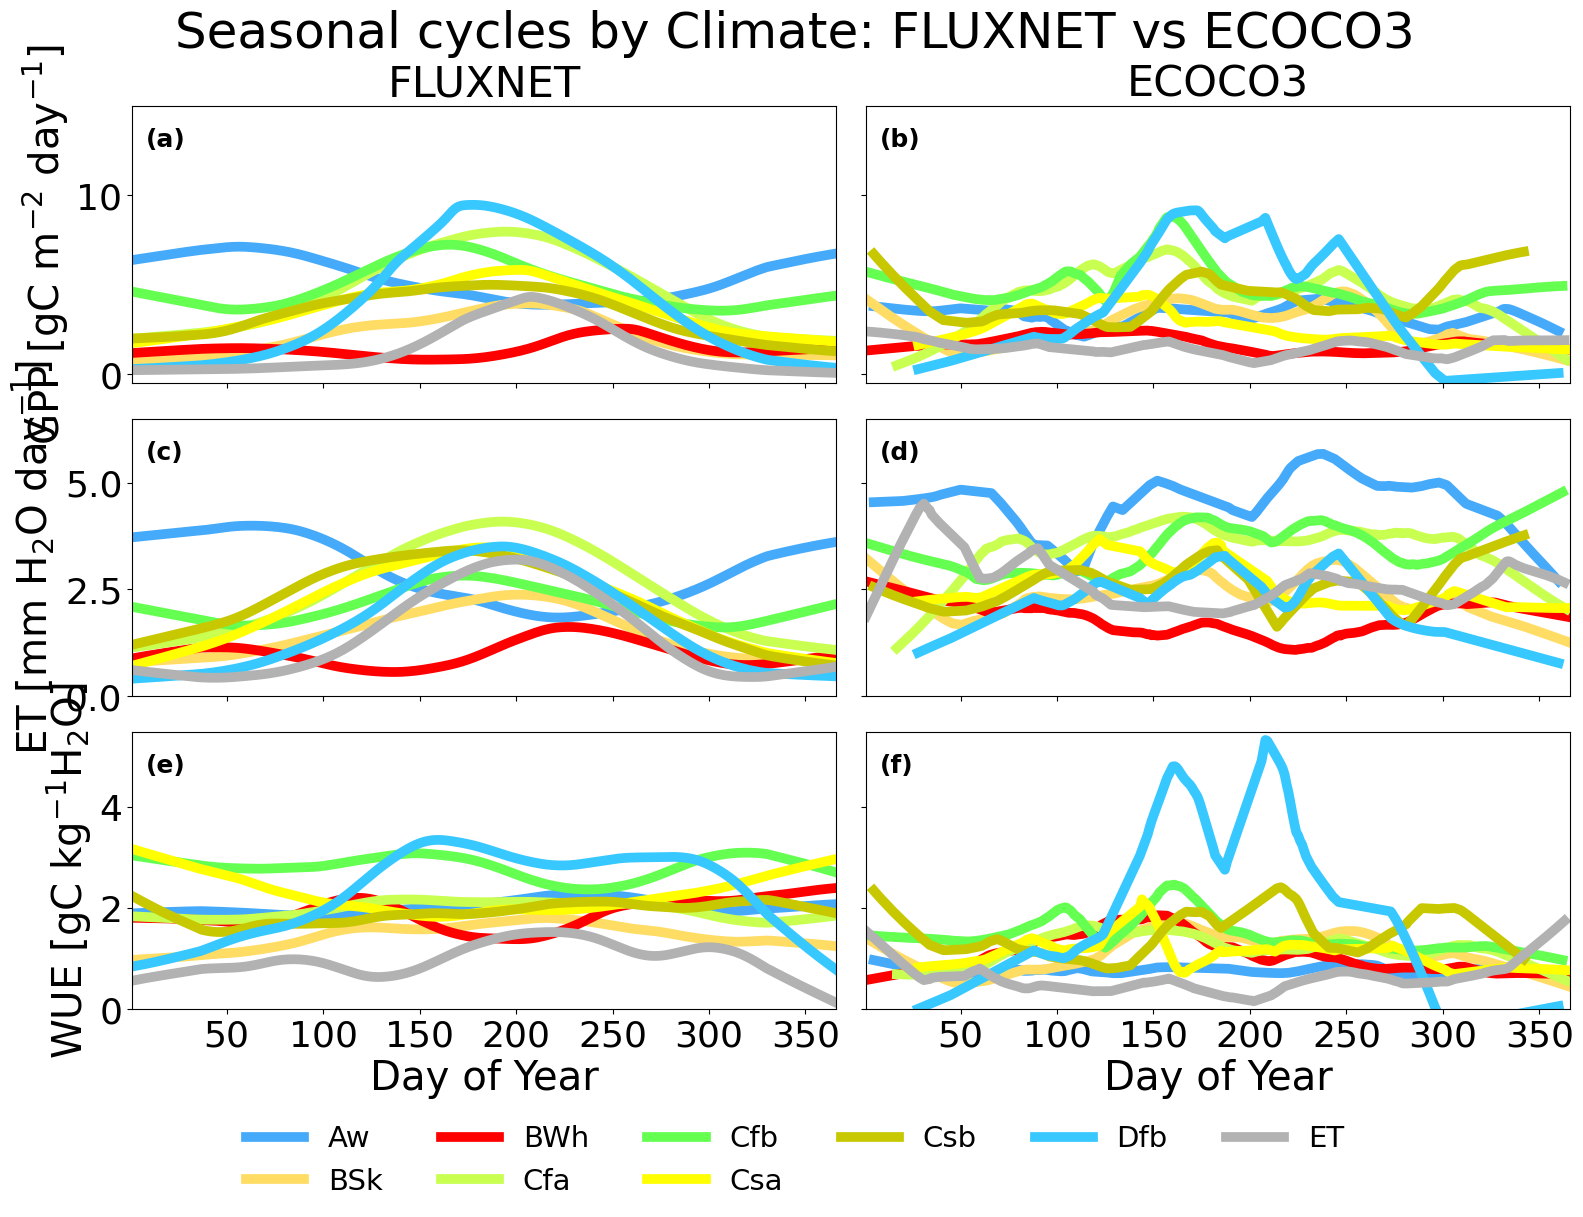

In [18]:
variables = ['GPP', 'ET', 'WUE']
y_labels = ['GPP [gC m$^{-2}$ day$^{-1}$]',
            'ET [mm H$_2$O day$^{-1}$]',
            'WUE [gC kg$^{-1}$H$_2$O]']

plot_scripts.plot_seasonal_cycles_comparison(
    df_fluxnet=df_wue_daily_fluxnet,
    df_ecoco3=df_wue_daily_ecoco3,
    variables=variables,
    y_labels=y_labels,
    group_type='Veg',  # or 'kg_label'
    frac=0.2,
    ylims=[[ -0.5, 13], [0, 5], [0, 5]],
    valid_veg=valid_veg,
    valid_kg=valid_kg,
    output_path='seasonal_cycles_comparison.png'  # optional
)

plot_scripts.plot_seasonal_cycles_comparison(
    df_fluxnet=df_wue_daily_fluxnet,
    df_ecoco3=df_wue_daily_ecoco3,
    variables=variables,
    y_labels=y_labels,
    group_type='kg_label',  # or 'kg_label'
    frac=0.2,
    ylims=[[ -0.5, 15], [0, 6.5], [0, 5.5]],
    valid_veg=valid_veg,
    valid_kg=valid_kg,
    output_path='seasonal_cycles_comparison.png'  # optional
)

/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,
/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,


/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,
/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,


/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,
/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,


/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,
/Users/zoepierratucsb/Documents/ECOCO3/plot_scripts.py:121: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(x=grouping_category, y='WUE', data=df_wue_daily, palette=color_map,


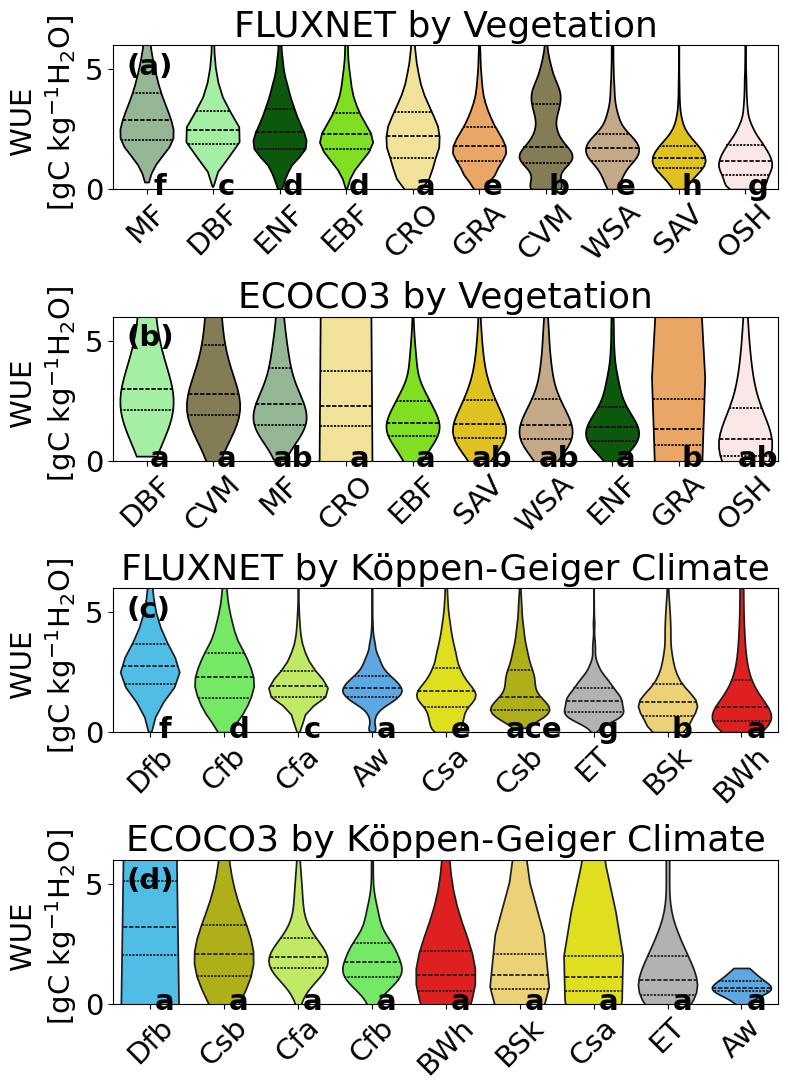

In [19]:
plot_scripts.plot_violin_comparison_stacked(
    df_ecoco3=df_wue_daily_ecoco3[df_wue_daily_ecoco3['Season'] == 'Summer'],
    df_fluxnet=df_wue_daily_fluxnet[df_wue_daily_fluxnet['Season'] == 'Summer'],
    grouping_category='Veg',  # or 'kg_label'
    valid_kg=valid_kg,
    valid_veg=valid_veg,
    output_path='/Users/zoepierratucsb/Library/CloudStorage/GoogleDrive-zpierrat@ucsb.edu/My Drive/PIE_Lab/Projects/ECOCO_Paper/Final_Figures/Figure3.png'
)

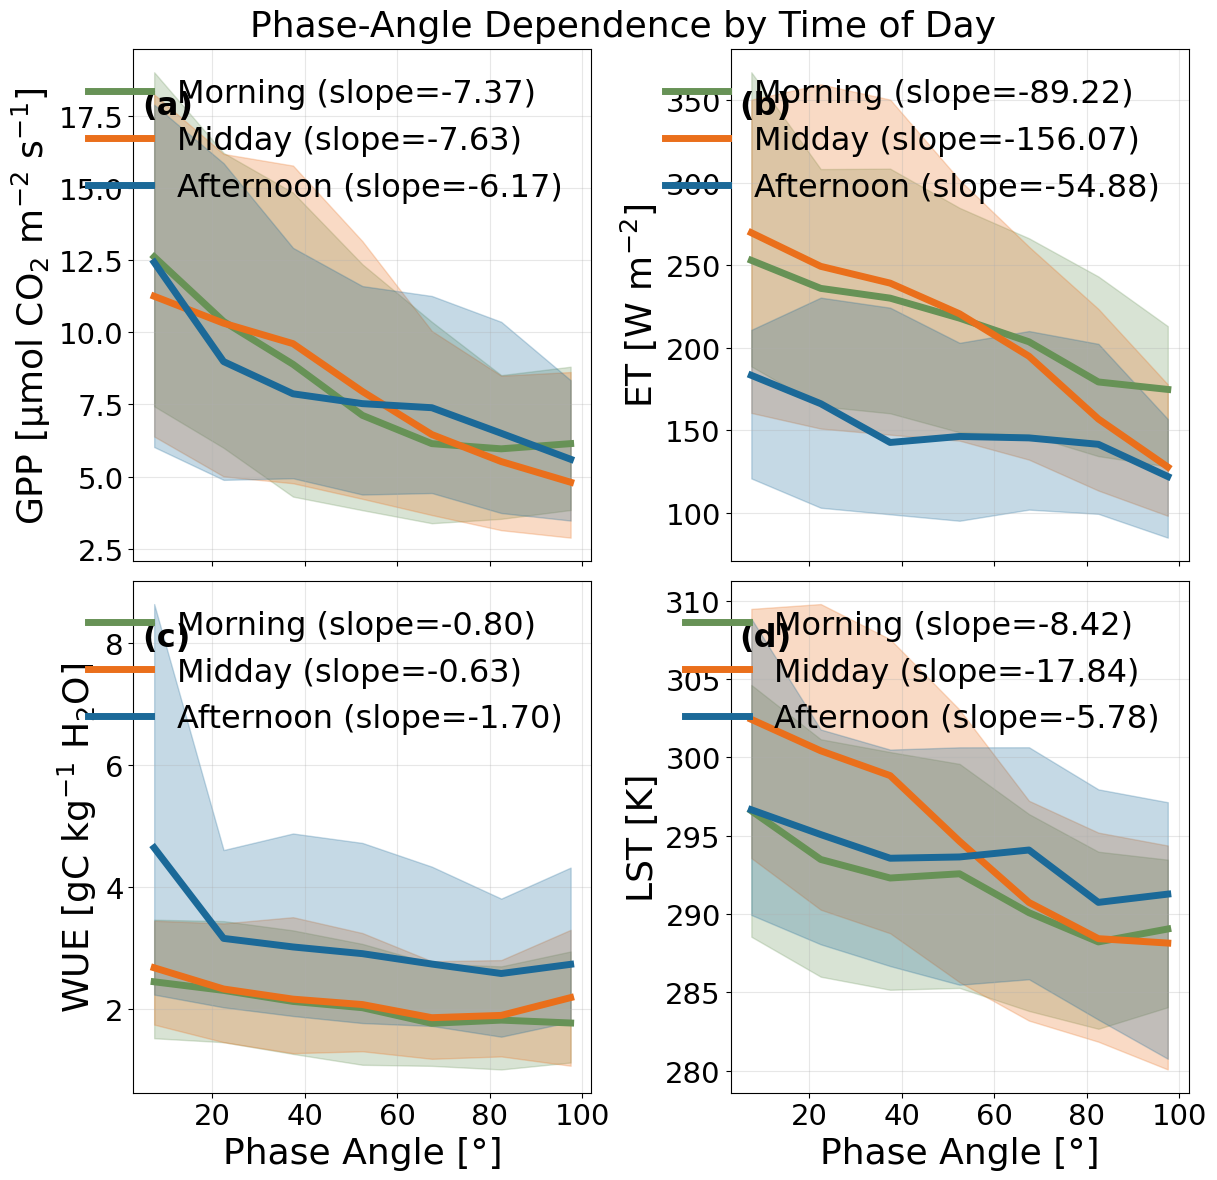

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# SETTINGS
# --------------------------
VARS = {
    'GPP': {'ylabel': 'GPP [μmol CO$_2$ m$^{-2}$ s$^{-1}$]'},
    'ET':  {'ylabel': 'ET [W m$^{-2}$]'},
    'WUE': {'ylabel': 'WUE [gC kg$^{-1}$ H$_2$O]'},
    'LST': {'ylabel': 'LST [K]'}
}

TOD_COLORS = {
    'Morning': '#679256',
    'Midday': '#ea6f1b',
    'Afternoon': '#1b6998'
}

TOD_ORDER = ['Morning', 'Midday', 'Afternoon']

PHASE_BINS = np.arange(0, 155, 15)
PHASE_CENTERS = (PHASE_BINS[:-1] + PHASE_BINS[1:]) / 2

MIN_N = 30

df_wue = df_wue_hh_ecoco3.copy()

# --------------------------
# FILTER
# --------------------------
df = df_wue[
    df_wue['Phase_Angle'].notnull() &
    df_wue['TOD'].isin(TOD_ORDER)
].copy()

df['Phase_bin'] = pd.cut(
    df['Phase_Angle'],
    bins=PHASE_BINS,
    labels=PHASE_CENTERS
).astype(float)

# --------------------------
# AGGREGATE — MEDIAN + IQR
# --------------------------
agg = (
    df.groupby(['TOD', 'Phase_bin'])
      .agg(
          GPP_med=('GPP', 'median'),
          GPP_q25=('GPP', lambda x: x.quantile(0.25)),
          GPP_q75=('GPP', lambda x: x.quantile(0.75)),

          ET_med=('ET', 'median'),
          ET_q25=('ET', lambda x: x.quantile(0.25)),
          ET_q75=('ET', lambda x: x.quantile(0.75)),

          WUE_med=('WUE', 'median'),
          WUE_q25=('WUE', lambda x: x.quantile(0.25)),
          WUE_q75=('WUE', lambda x: x.quantile(0.75)),

          LST_med=('LST', 'median'),
          LST_q25=('LST', lambda x: x.quantile(0.25)),
          LST_q75=('LST', lambda x: x.quantile(0.75)),

          N=('WUE', 'size')
      )
      .reset_index()
)

agg = agg[agg['N'] >= MIN_N]

# --------------------------
# PLOT
# --------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True)
axes = axes.flatten()   # <-- add this line
panel_labels = ['(a)', '(b)', '(c)', '(d)']

for i, (var, meta) in enumerate(VARS.items()):
    ax = axes[i]

    for tod, color in TOD_COLORS.items():
        sub = agg[agg['TOD'] == tod]
        if sub.empty:
            continue

        x = sub['Phase_bin'].values
        y = sub[f'{var}_med'].values
        q25 = sub[f'{var}_q25'].values
        q75 = sub[f'{var}_q75'].values

        # Compute slope per 100°
        slope, _ = np.polyfit(x, y, 1)
        slope_per100 = slope * 100

        # Plot median + IQR
        ax.plot(x, y, color=color, lw=5)
        ax.fill_between(x, q25, q75, color=color, alpha=0.25)

        # Add legend entry with slope
        ax.plot([], [], color=color, lw=5,
                label=f"{tod} (slope={slope_per100:.2f})")
                #label=f"{tod} (slope={slope_per100:.2f} {meta['ylabel'].split('[')[1].replace(']','')}/100°)")

    # Panel formatting
    ax.set_ylabel(meta['ylabel'], fontsize=26)
    ax.tick_params(axis='both', labelsize=21)
    ax.text(0.02, 0.92, panel_labels[i], transform=ax.transAxes,
            fontsize=23, fontweight='bold', va='top', ha='left')
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=23, ncol=1)  # each subplot gets its own legend

axes[-1].set_xlabel('Phase Angle [°]', fontsize=26)
axes[-2].set_xlabel('Phase Angle [°]', fontsize=26)

plt.suptitle('Phase-Angle Dependence by Time of Day', fontsize=26)
plt.tight_layout()
plt.savefig('/Users/zoepierratucsb/Library/CloudStorage/GoogleDrive-zpierrat@ucsb.edu/My Drive/PIE_Lab/Projects/ECOCO_Paper/Final_Figures/Figure6.png', dpi=300, bbox_inches='tight')
plt.show()

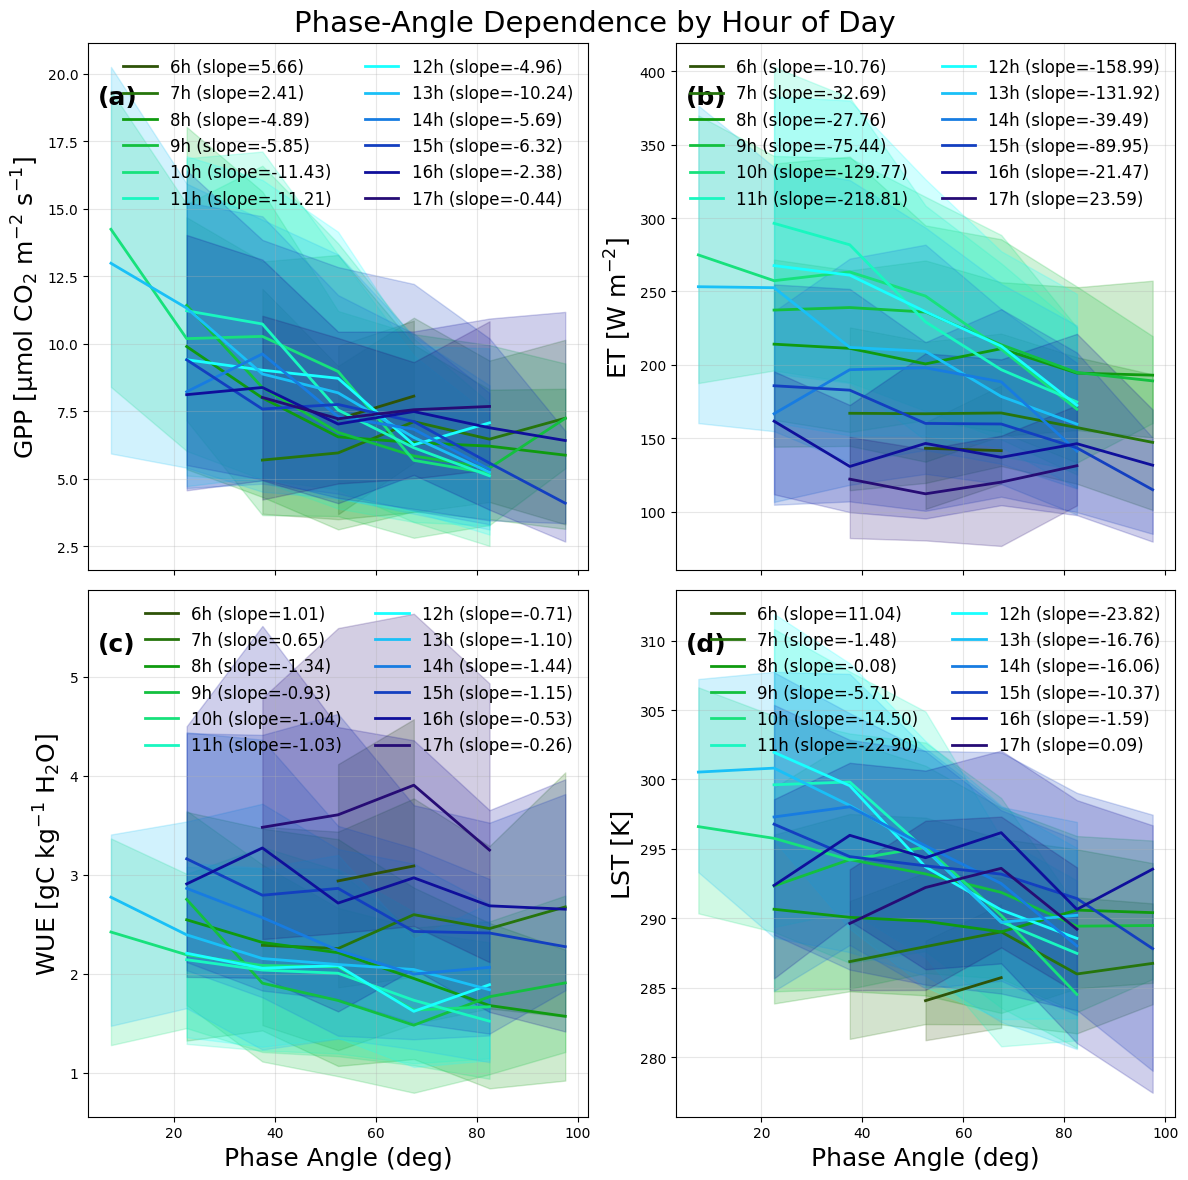

In [21]:
VARS = {
    'GPP': {'ylabel': 'GPP [μmol CO$_2$ m$^{-2}$ s$^{-1}$]'},
    'ET':  {'ylabel': 'ET [W m$^{-2}$]'},
    'WUE': {'ylabel': 'WUE [gC kg$^{-1}$ H$_2$O]'},
    'LST': {'ylabel': 'LST [K]'}
}

PHASE_BINS = np.arange(0, 155, 15)
PHASE_CENTERS = (PHASE_BINS[:-1] + PHASE_BINS[1:]) / 2
MIN_N = 30

df = df_wue_hh_ecoco3[df_wue_hh_ecoco3['Phase_Angle'].notnull()].copy()
df['Phase_bin'] = pd.cut(df['Phase_Angle'], bins=PHASE_BINS, labels=PHASE_CENTERS).astype(float)
df['Hour'] = df['Hour'].astype(int)

agg = (
    df.groupby(['Hour', 'Phase_bin'])
      .agg(
          GPP_med=('GPP', 'median'),
          GPP_q25=('GPP', lambda x: x.quantile(0.25)),
          GPP_q75=('GPP', lambda x: x.quantile(0.75)),
          ET_med=('ET', 'median'),
          ET_q25=('ET', lambda x: x.quantile(0.25)),
          ET_q75=('ET', lambda x: x.quantile(0.75)),
          WUE_med=('WUE', 'median'),
          WUE_q25=('WUE', lambda x: x.quantile(0.25)),
          WUE_q75=('WUE', lambda x: x.quantile(0.75)),
          LST_med=('LST', 'median'),
          LST_q25=('LST', lambda x: x.quantile(0.25)),
          LST_q75=('LST', lambda x: x.quantile(0.75)),
          N=('WUE', 'size')
      )
      .reset_index()
)
agg = agg[agg['N'] >= MIN_N]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True)
axes = axes.flatten()
panel_labels = ['(a)', '(b)', '(c)', '(d)']

hours = np.sort(agg['Hour'].unique())

colors = {h: af.hour_to_color(h) for h in hours}

for i, (var, meta) in enumerate(VARS.items()):
    ax = axes[i]
    for h in hours:
        sub = agg[agg['Hour'] == h]
        if sub.empty:
            continue
        x = sub['Phase_bin'].values
        y = sub[f'{var}_med'].values
        q25 = sub[f'{var}_q25'].values
        q75 = sub[f'{var}_q75'].values
        slope_per100 = np.polyfit(x, y, 1)[0] * 100
        ax.plot(x, y, color=colors[h], lw=2)
        ax.fill_between(x, q25, q75, color=colors[h], alpha=0.2)
        ax.plot([], [], color=colors[h], lw=2, label=f"{h}h (slope={slope_per100:.2f})")
    ax.set_ylabel(meta['ylabel'], fontsize=18)
    ax.text(0.02, 0.92, panel_labels[i], transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=12, ncol=2)

axes[-1].set_xlabel('Phase Angle (deg)', fontsize=18)
axes[-2].set_xlabel('Phase Angle (deg)', fontsize=18)
plt.suptitle('Phase-Angle Dependence by Hour of Day', fontsize=21)
plt.tight_layout()
plt.savefig('phase_angle_by_hour.png', dpi=300)
plt.show()

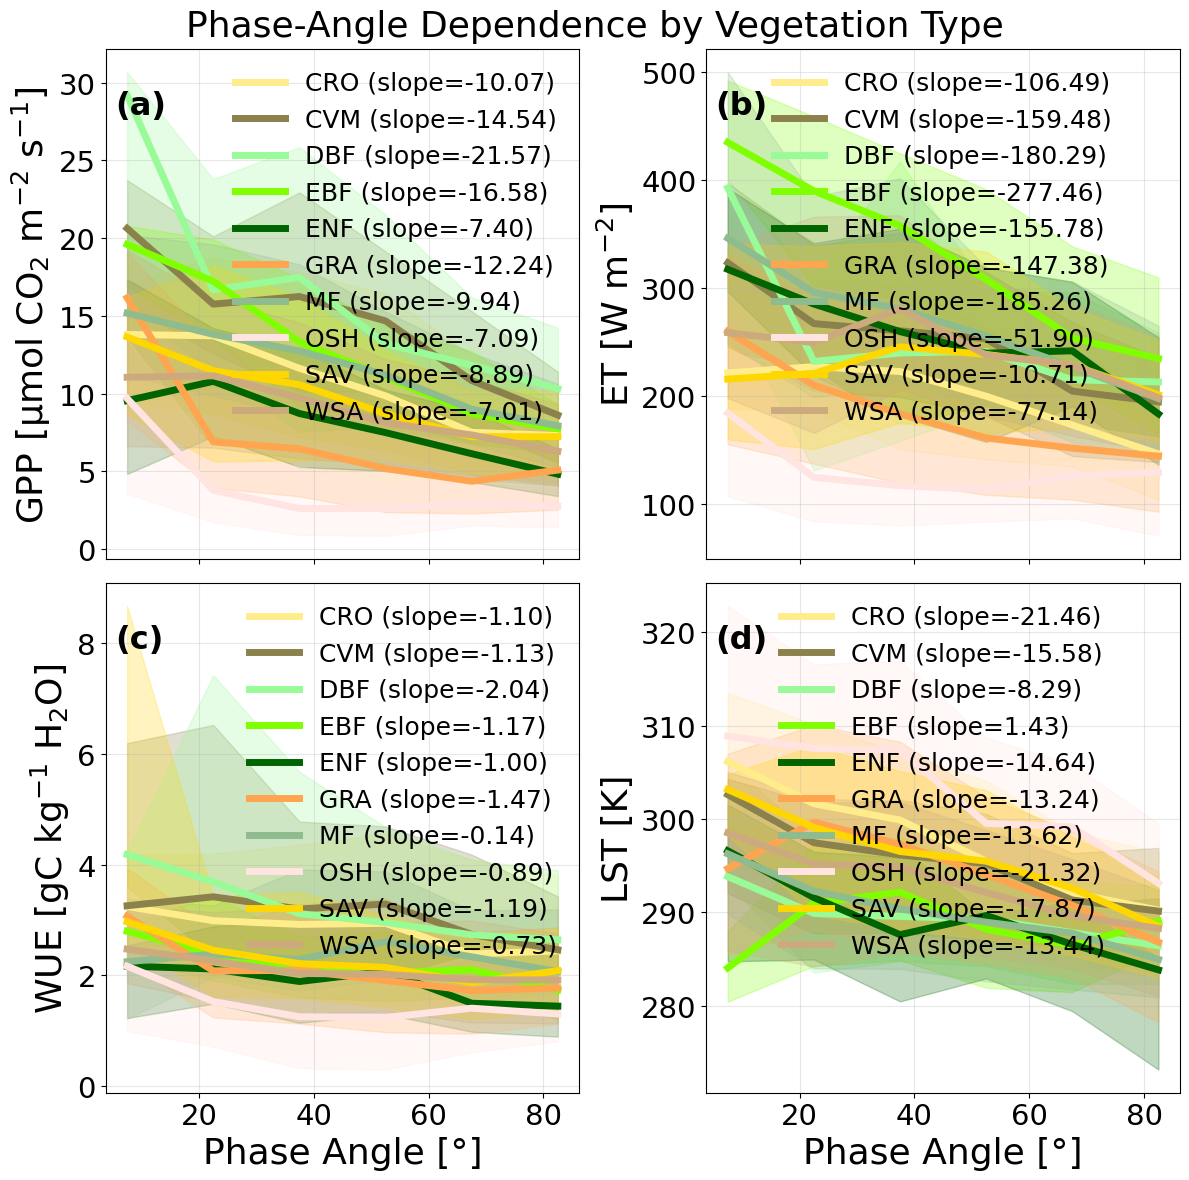

In [22]:
VARS = {
    'GPP': {'ylabel': 'GPP [μmol CO$_2$ m$^{-2}$ s$^{-1}$]'},
    'ET':  {'ylabel': 'ET [W m$^{-2}$]'},
    'WUE': {'ylabel': 'WUE [gC kg$^{-1}$ H$_2$O]'},
    'LST': {'ylabel': 'LST [K]'}
}

VEG_PALETTE = {
    'BSV': '#B0C4DE', 'CRO': '#FFEC8B', 'CSH': '#AB82FF', 'CVM': '#8B814C', 'DBF': '#98FB98',
    'DNF': '#9ACD32', 'EBF': '#7FFF00', 'ENF': '#006400', 'GRA': '#FFA54F', 'MF': '#8FBC8F',
    'OSH': '#FFE4E1', 'SAV': '#FFD700', 'SNO': '#000000', 'URB': '#FF0000', 'WAT': '#98F5FF',
    'WET': '#4169E1', 'WSA': '#CDAA7D',
}

PHASE_BINS = np.arange(0, 100, 15)
PHASE_CENTERS = (PHASE_BINS[:-1] + PHASE_BINS[1:]) / 2
MIN_N = 1

df = df_wue_hh_ecoco3[df_wue_hh_ecoco3['Phase_Angle'].notnull()].copy()
df = df[df['Veg'].isin(valid_veg) & df['kg_label'].isin(valid_kg)]
df['Phase_bin'] = pd.cut(df['Phase_Angle'], bins=PHASE_BINS, labels=PHASE_CENTERS).astype(float)

agg = (
    df.groupby(['Veg', 'Phase_bin'])
      .agg(
          GPP_med=('GPP', 'median'),
          GPP_q25=('GPP', lambda x: x.quantile(0.25)),
          GPP_q75=('GPP', lambda x: x.quantile(0.75)),
          ET_med=('ET', 'median'),
          ET_q25=('ET', lambda x: x.quantile(0.25)),
          ET_q75=('ET', lambda x: x.quantile(0.75)),
          WUE_med=('WUE', 'median'),
          WUE_q25=('WUE', lambda x: x.quantile(0.25)),
          WUE_q75=('WUE', lambda x: x.quantile(0.75)),
          LST_med=('LST', 'median'),
          LST_q25=('LST', lambda x: x.quantile(0.25)),
          LST_q75=('LST', lambda x: x.quantile(0.75)),
          N=('WUE', 'size')
      )
      .reset_index()
)
agg = agg[agg['N'] >= MIN_N]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True)
axes = axes.flatten()
panel_labels = ['(a)', '(b)', '(c)', '(d)']

for i, (var, meta) in enumerate(VARS.items()):
    ax = axes[i]
    for veg, color in VEG_PALETTE.items():
        sub = agg[agg['Veg'] == veg]
        if sub.empty:
            continue
        x = sub['Phase_bin'].values
        y = sub[f'{var}_med'].values
        q25 = sub[f'{var}_q25'].values
        q75 = sub[f'{var}_q75'].values
        slope_per100 = np.polyfit(x, y, 1)[0] * 100
        ax.plot(x, y, color=color, lw=5)
        ax.fill_between(x, q25, q75, color=color, alpha=0.25)
        ax.plot([], [], color=color, lw=5, label=f"{veg} (slope={slope_per100:.2f})")
    ax.set_ylabel(meta['ylabel'], fontsize=26)
    ax.tick_params(axis='both', labelsize=21)
    ax.text(0.02, 0.92, panel_labels[i], transform=ax.transAxes,
            fontsize=23, fontweight='bold', va='top', ha='left')
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=18, ncol=1)

axes[-1].set_xlabel('Phase Angle [°]', fontsize=26)
axes[-2].set_xlabel('Phase Angle [°]', fontsize=26)
plt.suptitle('Phase-Angle Dependence by Vegetation Type', fontsize=26)
plt.tight_layout()
plt.savefig('phase_angle_by_veg.png', dpi=300)
plt.show()

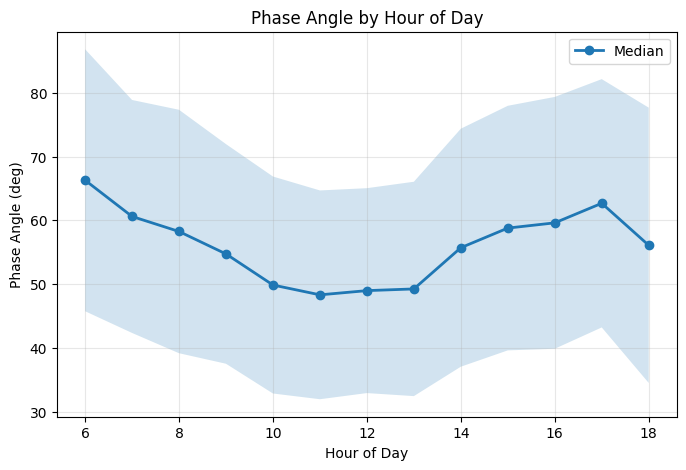

In [23]:
df = df_wue_hh_ecoco3[df_wue_hh_ecoco3['Phase_Angle'].notnull()].copy()

hour_stats = (
    df.groupby('Hour')['Phase_Angle']
      .agg(['median', 'mean', 'std', 'count'])
      .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(hour_stats['Hour'], hour_stats['median'], marker='o', lw=2, label='Median')
plt.fill_between(
    hour_stats['Hour'],
    hour_stats['median'] - hour_stats['std'],
    hour_stats['median'] + hour_stats['std'],
    alpha=0.2
)
plt.xlabel('Hour of Day')
plt.ylabel('Phase Angle (deg)')
plt.title('Phase Angle by Hour of Day')
plt.grid(alpha=0.3)
plt.legend()
plt.show()